# Objetivos
Construir el grafico con puntos fisicos



In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

# === CAMBIO FUNDAMENTAL: Link a tu repo en WSL ===
# Agregamos la ruta de 'mlpython' al sistema para poder importar 'lib'
# Esto funciona aunque estés ejecutando el notebook en cern_db
repo_path = os.path.expanduser("~/dihiggs/mlpython")
if repo_path not in sys.path:
    sys.path.append(repo_path)

# Ahora sí podemos importar tu librería
import lib  
from lib import plot_branchings, physpoint, plot_branchings_and_lifetime

print(f"✅ Librería cargada correctamente desde: {repo_path}")

✅ Librería cargada correctamente desde: /home/fabi/dihiggs/mlpython


In [5]:
# !pip install tqdm -qqq

In [6]:
# === CELDA 2 INSTRUMENTADA: Carga Optimizada con Feedback ===
import os
import pandas as pd
import time
from tqdm import tqdm # Barra de progreso estándar en Data Science

# 1. Configuración de Rutas
INDEX_FILE = "/mnt/c/Users/Asus/cern_db/verified_file_index.csv"
LOCAL_ROOT = "/mnt/c/Users/Asus/cern_db"
REMOTE_ROOT = "/eos/home-f/ftrigofa/DB_dihiggs" # La parte a eliminar

print(f"⏱️ Inicio del proceso. Hora: {time.strftime('%H:%M:%S')}")
t_start = time.time()

# 2. Cargar Índice
if not os.path.exists(INDEX_FILE):
    raise FileNotFoundError(f"❌ No encuentro el índice en: {INDEX_FILE}")

df_index = pd.read_csv(INDEX_FILE)
print(f"📂 Índice cargado: {len(df_index)} archivos listados.")

# 3. Preparación de Rutas (Vectorizado es más rápido, pero usaremos bucle para control)
valid_dfs = []
missing_files = []

# Iteramos con barra de progreso
print("🚀 Iniciando lectura de CSVs...")
for i, original_path in tqdm(enumerate(df_index['file_path']), total=len(df_index), unit="files"):
    
    # --- LOGICA DE REEMPLAZO ---
    # Convertimos ruta SWAN -> Ruta WSL
    if original_path.startswith(REMOTE_ROOT):
        # Opción A: Reemplazo directo (El índice tiene la estructura completa)
        local_path = original_path.replace(REMOTE_ROOT, LOCAL_ROOT)
    else:
        # Opción B: Si la ruta en el índice es extraña, asumimos estructura estándar
        filename = os.path.basename(original_path)
        # Asumimos que están en dihiggs_lake/campaign/run_id/filename ???
        # Ojo: Ajusta esto si tus archivos están "sueltos" en cern_db
        # Si descargaste todo plano, usa: os.path.join(LOCAL_ROOT, filename)
        
        # Intento 1: Buscar tal cual
        local_path = os.path.join(LOCAL_ROOT, original_path.strip('/')) 
    
    # --- DEBUGGING DEL PRIMER CASO ---
    if i == 0:
        print(f"\n🔍 DEBUG RUTA (Archivo #0):")
        print(f"   Original: {original_path}")
        print(f"   Calculada: {local_path}")
        print(f"   ¿Existe?: {'✅ SÍ' if os.path.exists(local_path) else '❌ NO'}")
        if not os.path.exists(local_path):
            print("   ⚠️ ALERTA: La transformación de ruta falló. Revisa LOCAL_ROOT.")
            # Intento de corrección heurística para el usuario:
            # Si el archivo está en una subcarpeta interna tipo 'dihiggs_lake'
            alt_path = local_path.replace(LOCAL_ROOT, os.path.join(LOCAL_ROOT, "dihiggs_lake"))
            if os.path.exists(alt_path):
                print(f"   💡 SUGERENCIA: Parece que te falta 'dihiggs_lake' en la ruta. Ajustando...")
                local_path = alt_path # Auto-fix para el loop

    # --- LECTURA ---
    if os.path.exists(local_path):
        try:
            # Leemos
            df_temp = pd.read_csv(local_path)
            valid_dfs.append(df_temp)
        except Exception as e:
            print(f"   ❌ Error corrupto en {os.path.basename(local_path)}")
    else:
        missing_files.append(local_path)

# 4. Concatenación
print("\n🔗 Fusionando DataFrames...")
if valid_dfs:
    df_read = pd.concat(valid_dfs, ignore_index=True)
    t_end = time.time()
    
    print("-" * 50)
    print(f"✅ PROCESO TERMINADO en {t_end - t_start:.2f} segs")
    print(f"📊 Archivos leídos: {len(valid_dfs)} / {len(df_index)}")
    print(f"📈 Total Puntos: {len(df_read)}")
    
    if missing_files:
        print(f"⚠️ {len(missing_files)} archivos NO encontrados.")
        print(f"   Ejemplo perdido: {missing_files[0]}")
    
    display(df_read.head())
else:
    print("❌ ERROR FATAL: No se cargó ningún archivo. Revisa las rutas.")

⏱️ Inicio del proceso. Hora: 02:56:12
📂 Índice cargado: 42 archivos listados.
🚀 Iniciando lectura de CSVs...


  0%|          | 0/42 [00:00<?, ?files/s]


🔍 DEBUG RUTA (Archivo #0):
   Original: /eos/home-f/ftrigofa/DB_dihiggs/dihiggs_lake/campaign=legacy_recovered_v1/fixed_sinba=0p9900_l6=0p1000_l7=0p0000_mA=300p0000/run_legacy_import_20260128/tb_00010/scan_legacy_0c0adfcf.csv
   Calculada: /mnt/c/Users/Asus/cern_db/dihiggs_lake/campaign=legacy_recovered_v1/fixed_sinba=0p9900_l6=0p1000_l7=0p0000_mA=300p0000/run_legacy_import_20260128/tb_00010/scan_legacy_0c0adfcf.csv
   ¿Existe?: ✅ SÍ


100%|██████████| 42/42 [04:00<00:00,  5.73s/files]



🔗 Fusionando DataFrames...
--------------------------------------------------
✅ PROCESO TERMINADO en 244.08 segs
📊 Archivos leídos: 42 / 42
📈 Total Puntos: 6915000


,m_phi,mA,alpha,beta,lambda6,lambda7,m12,sin_ba,tan_beta,positivity_ok,...,width_hh,total_width,br_gaga,lam1,computed_lam1,lam2,computed_lam2,lam3,lam4,lam5
0,141.4286,300.0,0.041871,1.471128,0.1,0.0,1909.562,0.99,10.0,0.0,...,0.0,0.000111,0.003759,0.000000,-0.002686,0.257769,0.257308,2.676459,-1.171415,-1.171415
1,141.4286,300.0,0.041871,1.471128,0.1,0.0,1909.202,0.99,10.0,0.0,...,0.0,0.000111,0.003759,0.006003,0.003306,0.257770,0.257308,2.676519,-1.171475,-1.171475
2,141.4286,300.0,0.041871,1.471128,0.1,0.0,1908.843,0.99,10.0,0.0,...,0.0,0.000111,0.003758,0.012006,0.009298,0.257770,0.257309,2.676579,-1.171535,-1.171535
3,141.4286,300.0,0.041871,1.471128,0.1,0.0,1908.483,0.99,10.0,0.0,...,0.0,0.000111,0.003758,0.018009,0.015291,0.257771,0.257309,2.676639,-1.171595,-1.171595
4,141.4286,300.0,0.041871,1.471128,0.1,0.0,1908.123,0.99,10.0,0.0,...,0.0,0.000111,0.003757,0.024012,0.021283,0.257771,0.257310,2.676699,-1.171655,-1.171655


In [7]:
# --- Paso 1: Crear un DataFrame de ejemplo con puntos físicos ---
# Columnas: m_phi, m12_2, positivity_ok, unitarity_ok, perturbativity_ok
# df_read = pd.read_csv('./output/filtered_data_1003.csv')

# --- Paso 2: Filtrar solo los puntos físicos donde positivity_ok, unitarity_ok y perturbativity_ok == 1 ---
df_physical = df_read[
    (df_read['positivity_ok'] == 1) &
    (df_read['unitarity_ok']  == 1) &
    (df_read['perturbativity_ok'] == 1)
].reset_index(drop=True)


print(len(df_physical))
df_physical.head()

print(df_physical.columns)

259918
Index(['m_phi', 'mA', 'alpha', 'beta', 'lambda6', 'lambda7', 'm12', 'sin_ba',
       'tan_beta', 'positivity_ok', 'unitarity_ok', 'perturbativity_ok',
       'width_bb', 'width_tautau', 'width_WW', 'width_ZZ', 'width_gaga',
       'width_Zga', 'width_gg', 'width_hh', 'total_width', 'br_gaga', 'lam1',
       'computed_lam1', 'lam2', 'computed_lam2', 'lam3', 'lam4', 'lam5'],
      dtype='object')


<Axes: >

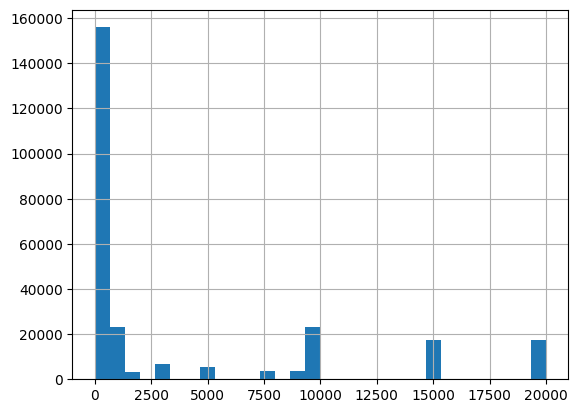

In [8]:
df_physical.tan_beta.hist(bins=30)

<Axes: >

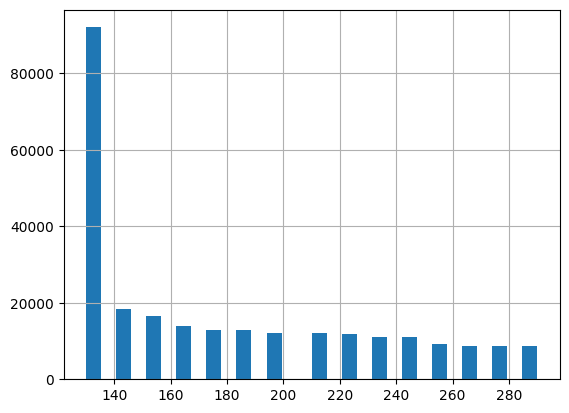

In [9]:
df_physical.m_phi.hist(bins=30)

In [10]:
(df_physical["m_phi"] < 141).sum()

np.int64(92042)

In [11]:
df_physical.columns

Index(['m_phi', 'mA', 'alpha', 'beta', 'lambda6', 'lambda7', 'm12', 'sin_ba',
       'tan_beta', 'positivity_ok', 'unitarity_ok', 'perturbativity_ok',
       'width_bb', 'width_tautau', 'width_WW', 'width_ZZ', 'width_gaga',
       'width_Zga', 'width_gg', 'width_hh', 'total_width', 'br_gaga', 'lam1',
       'computed_lam1', 'lam2', 'computed_lam2', 'lam3', 'lam4', 'lam5'],
      dtype='object')

In [12]:
set(df_physical.tan_beta)

{10.0,
 50.0,
 100.0,
 200.0,
 500.0,
 1000.0,
 1500.0,
 2000.0,
 3000.0,
 5000.0,
 8000.0,
 9000.0,
 10000.0,
 15000.0,
 20000.0}

In [13]:
print(df_physical.columns.tolist())

['m_phi', 'mA', 'alpha', 'beta', 'lambda6', 'lambda7', 'm12', 'sin_ba', 'tan_beta', 'positivity_ok', 'unitarity_ok', 'perturbativity_ok', 'width_bb', 'width_tautau', 'width_WW', 'width_ZZ', 'width_gaga', 'width_Zga', 'width_gg', 'width_hh', 'total_width', 'br_gaga', 'lam1', 'computed_lam1', 'lam2', 'computed_lam2', 'lam3', 'lam4', 'lam5']


In [14]:
# Valores fijos (mismos que en physpoint y simulate_curve)
fixed_mA      = 300.0
fixed_sin_ba  = 0.9990
fixed_lambda6 = 0.1
fixed_lambda7 = 0.0

# Valores de tan_beta a considerar
tan_beta_vals = set(df_physical.tan_beta)


def get_curve(df, fixed_mA, fixed_sin_ba, fixed_lambda6, fixed_lambda7, tan_beta_vals, tol=1e-3):
    # Filtro por parámetros fijos (excepto tan_beta)
    mask_fixed = (
        (df['mA'].sub(fixed_mA).abs() < tol) &
        (df['sin_ba'].sub(fixed_sin_ba).abs() < tol) &
        (df['lambda6'].sub(fixed_lambda6).abs() < tol) &
        (df['lambda7'].sub(fixed_lambda7).abs() < tol) &
        (df['tan_beta'].isin(tan_beta_vals))
    )
    return df.loc[mask_fixed].copy().reset_index(drop=True)

df_physical_curve = get_curve(df_physical, fixed_mA, fixed_sin_ba, fixed_lambda6, fixed_lambda7, tan_beta_vals, tol=1e-3)



In [15]:
# # # ==== extrae un valor de ejemplo =====
# fixed_mphi = 200
# mask_phi = df_physical['m_phi'].sub(fixed_mphi).abs() < 1
# df_curve.loc[mask_phi].iloc[0]

## Analisis Loop
Aqui pruebo 

🔍 Espacio de parámetros detectado:
   mA:      [np.float64(300.0)]
   lambda6: [np.float64(0.1)]
   lambda7: [np.float64(0.0)]
   sin_ba:  [np.float64(0.99), np.float64(0.995), np.float64(0.999), np.float64(0.9995), np.float64(0.9999)]
--------------------------------------------------

📍 Escenario: mA=300.0, l6=0.1, l7=0.0
   👉 Analizando sin(b-a) = 0.99
      📈 Ploteando tanβ=10.0 (N=62420)


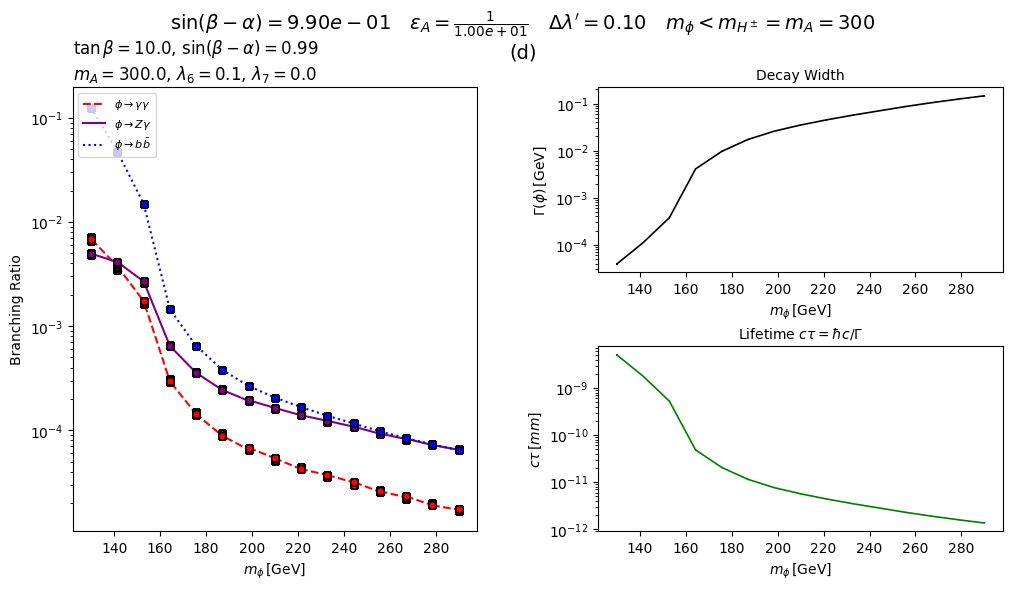

      📈 Ploteando tanβ=50.0 (N=10341)


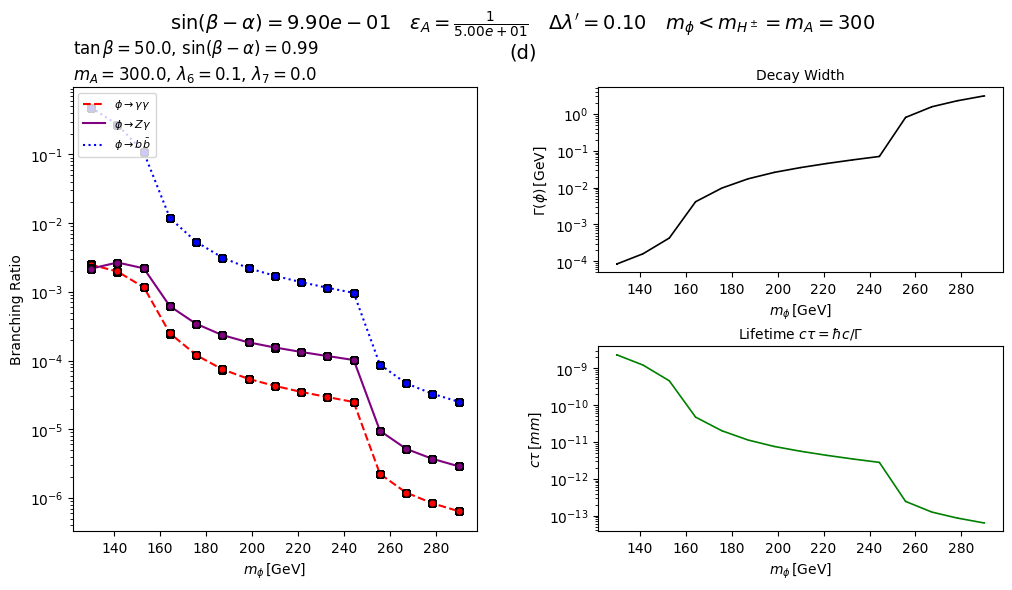

      📈 Ploteando tanβ=100.0 (N=8148)


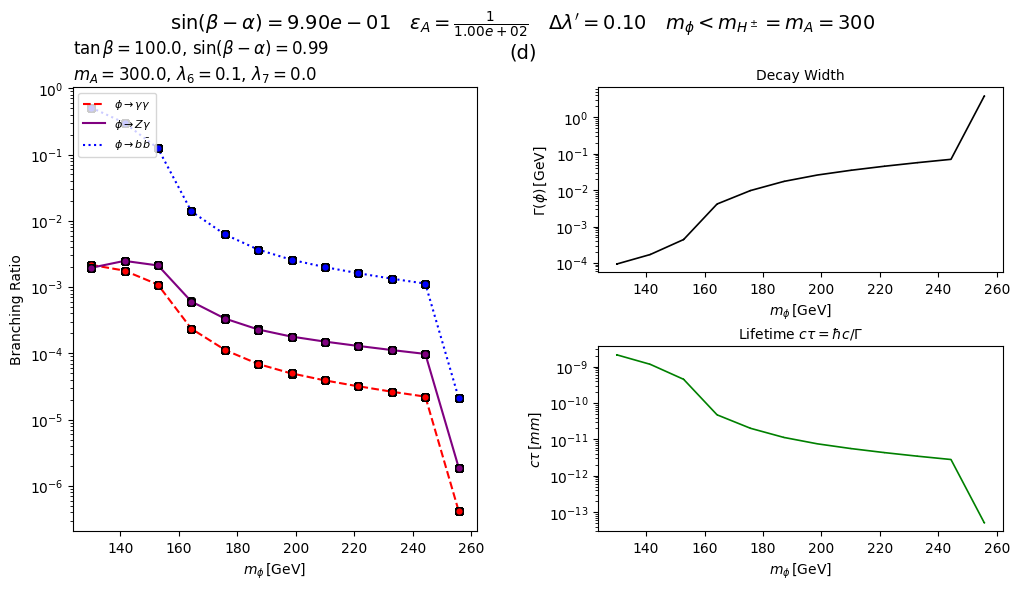

      📈 Ploteando tanβ=200.0 (N=4095)


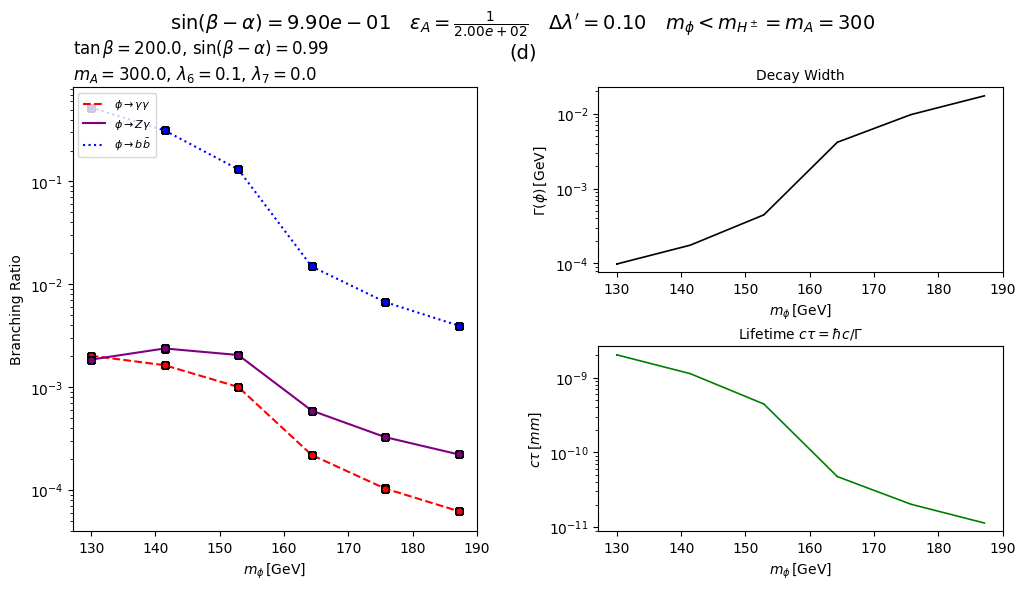

      📈 Ploteando tanβ=500.0 (N=2036)


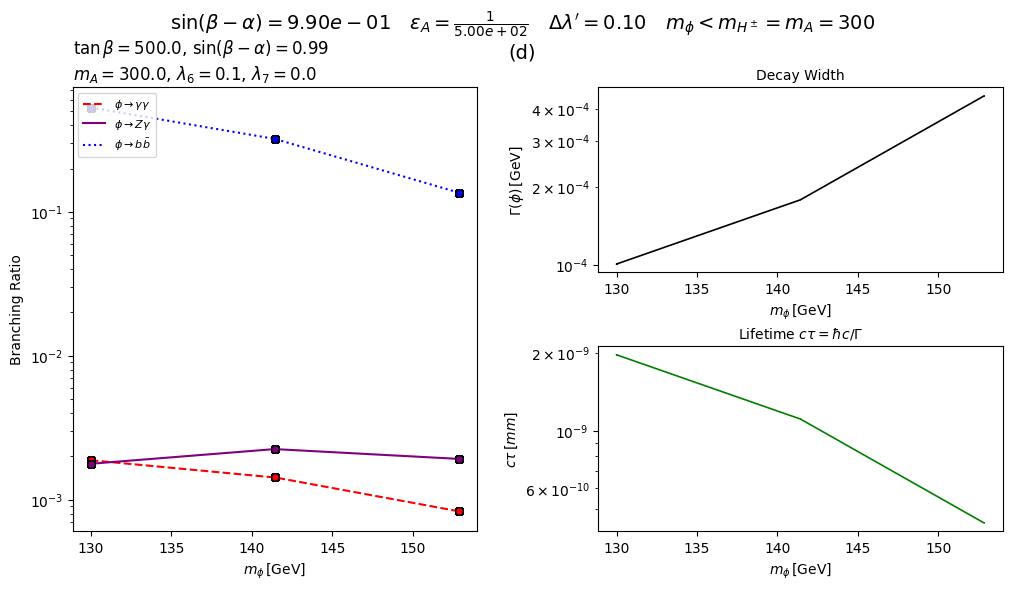

      📈 Ploteando tanβ=1000.0 (N=1344)


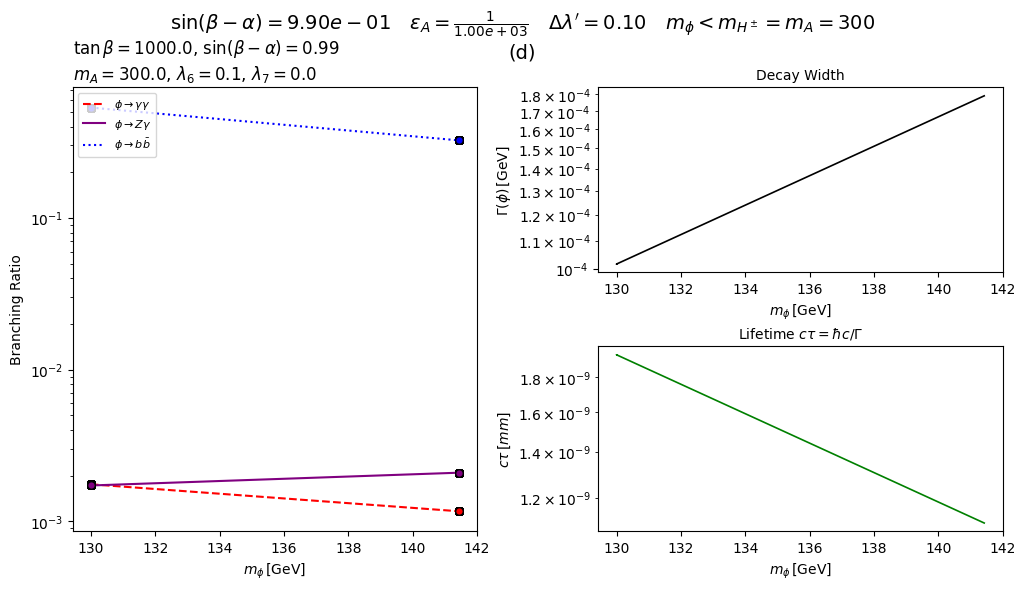

      📈 Ploteando tanβ=1500.0 (N=686)


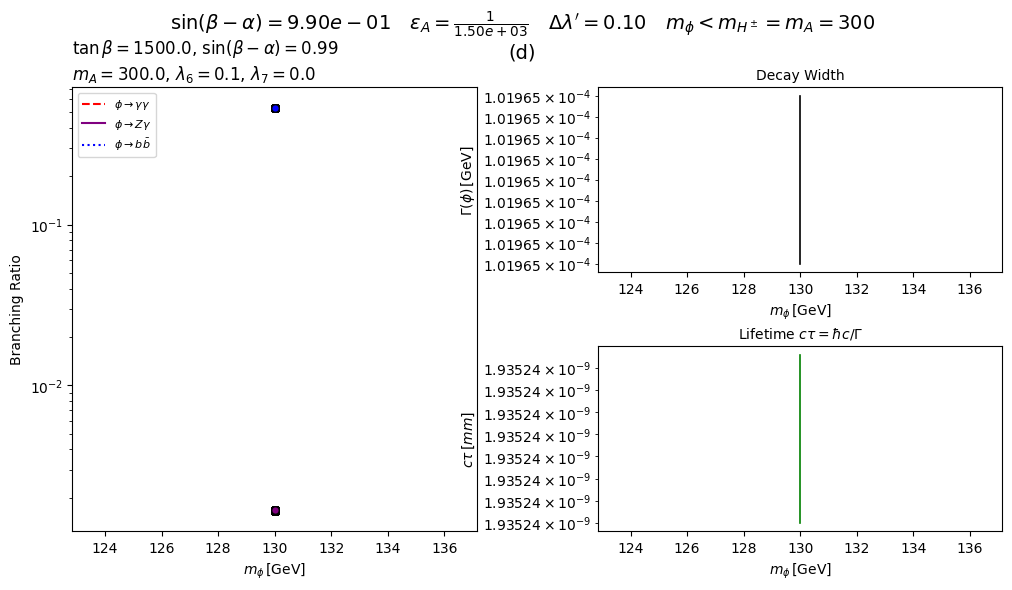

      📈 Ploteando tanβ=2000.0 (N=676)


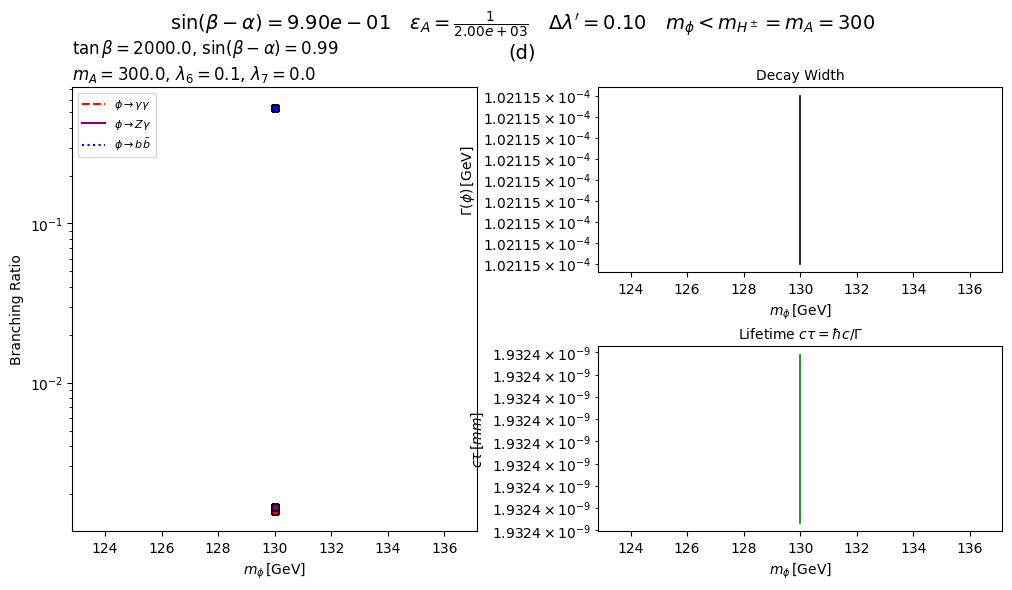

   👉 Analizando sin(b-a) = 0.995
      📈 Ploteando tanβ=100.0 (N=10326)


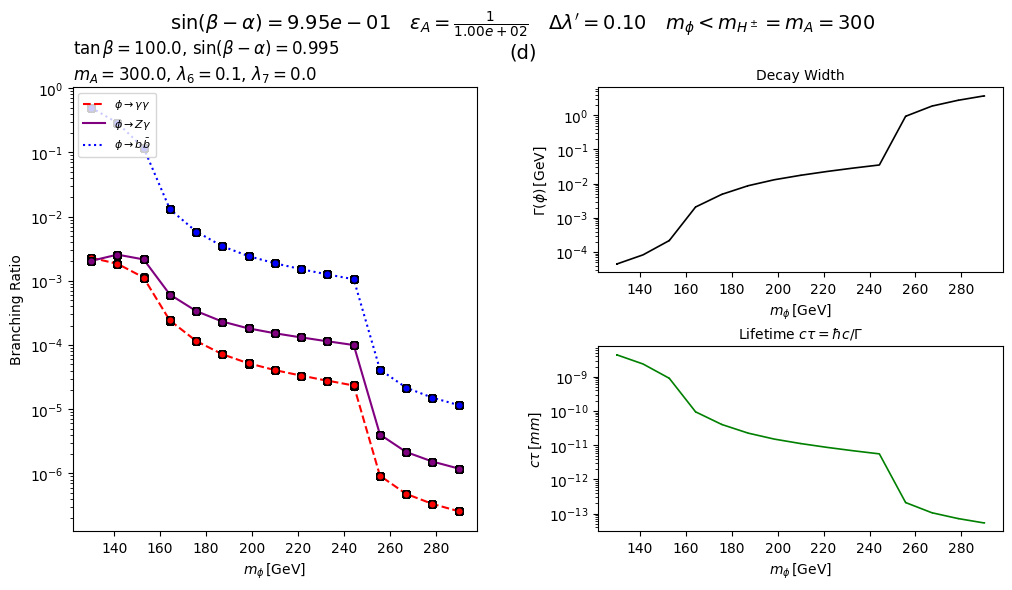

      📈 Ploteando tanβ=200.0 (N=6182)


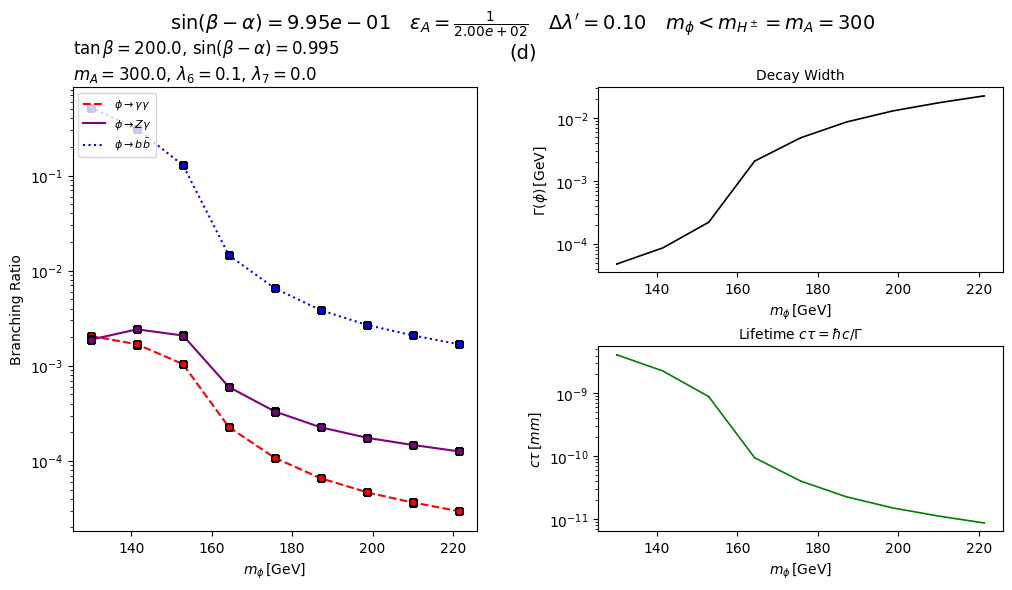

      📈 Ploteando tanβ=500.0 (N=2750)


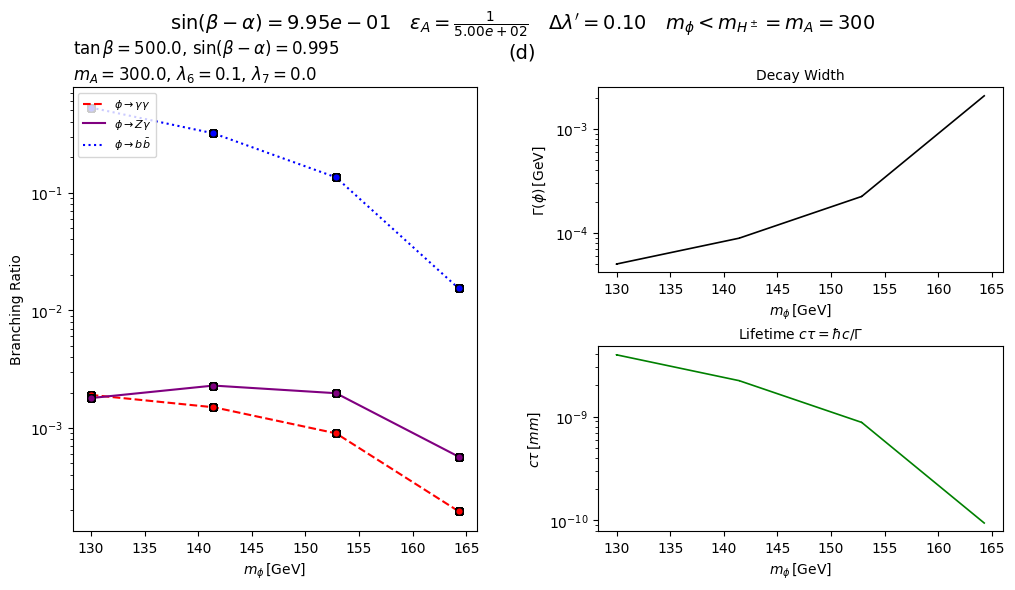

      📈 Ploteando tanβ=1000.0 (N=1378)


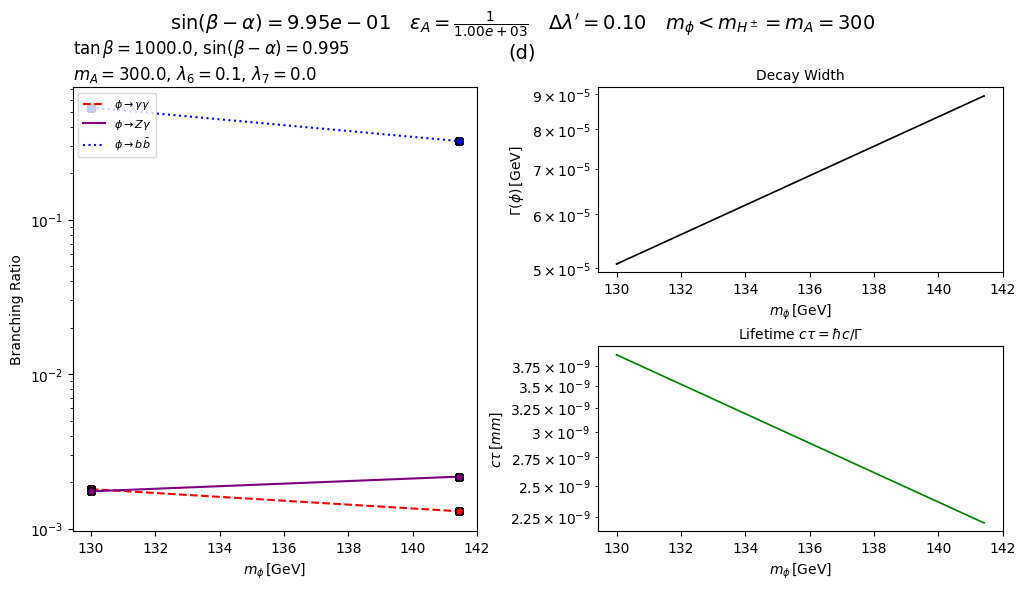

      📈 Ploteando tanβ=3000.0 (N=6844)


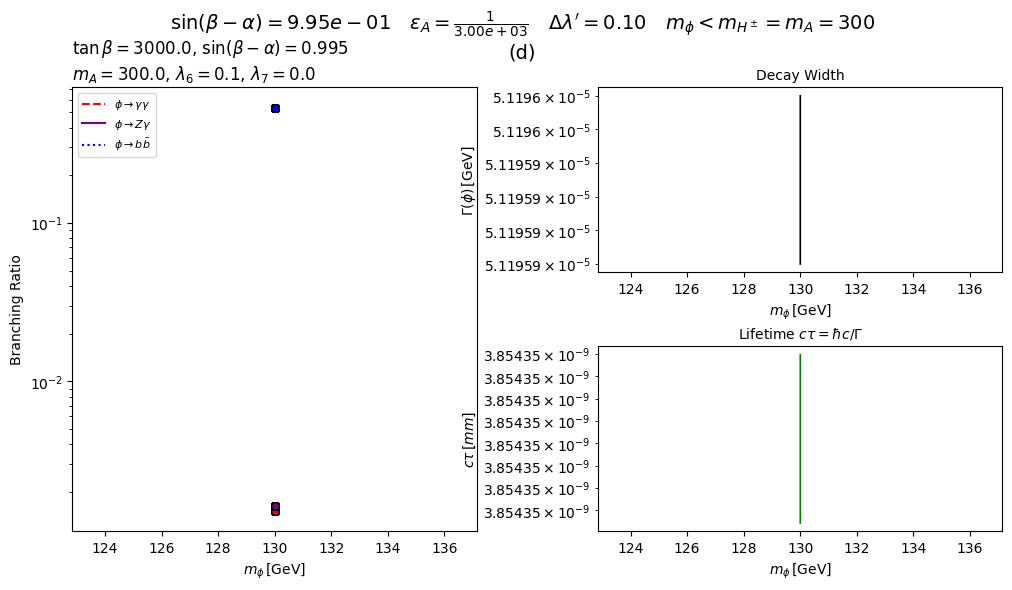

   👉 Analizando sin(b-a) = 0.999
      📈 Ploteando tanβ=10.0 (N=5241)


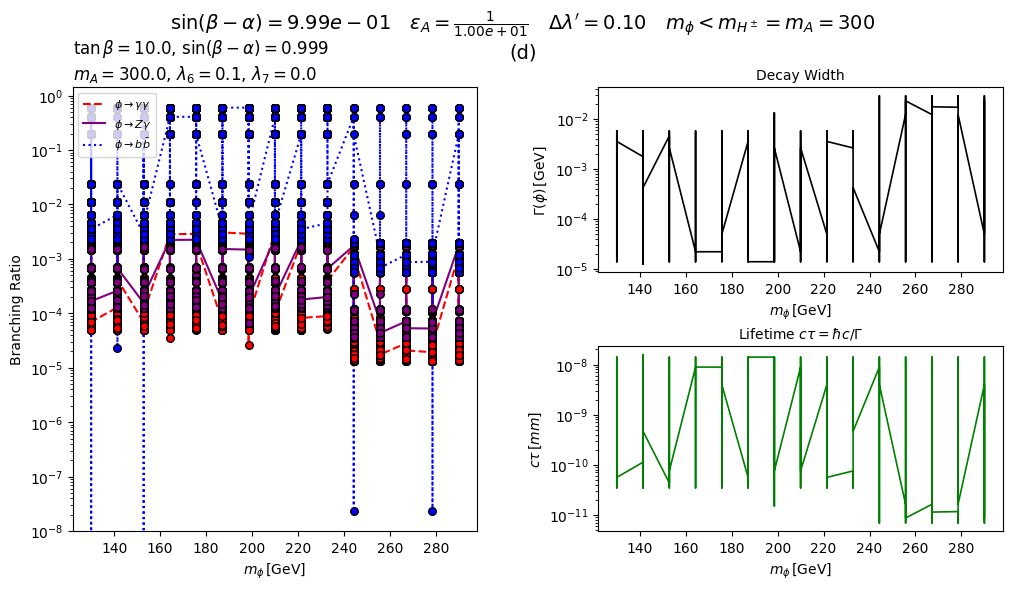

      📈 Ploteando tanβ=50.0 (N=5201)


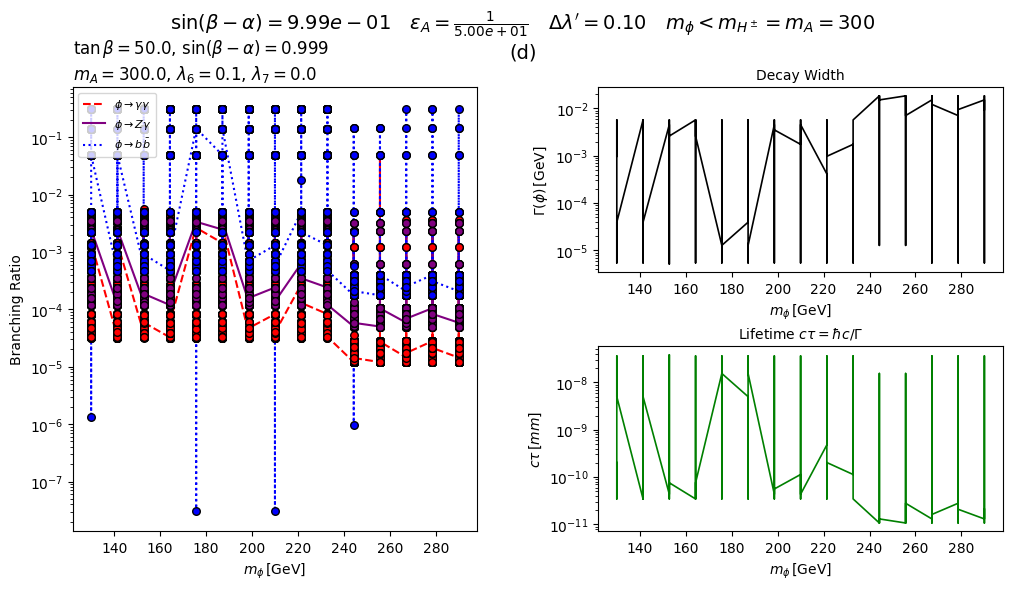

      📈 Ploteando tanβ=100.0 (N=5211)


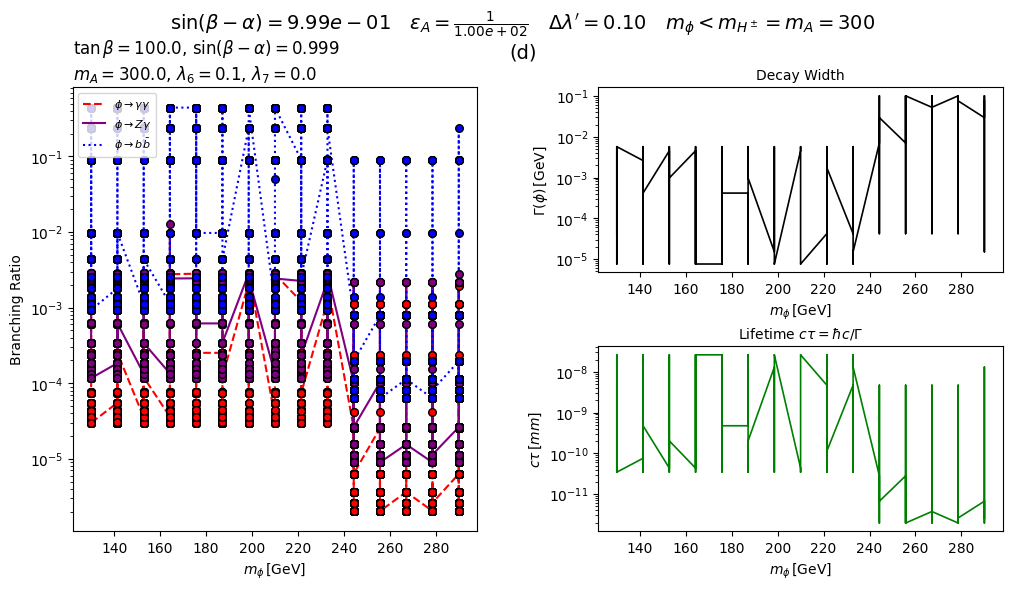

      📈 Ploteando tanβ=200.0 (N=5210)


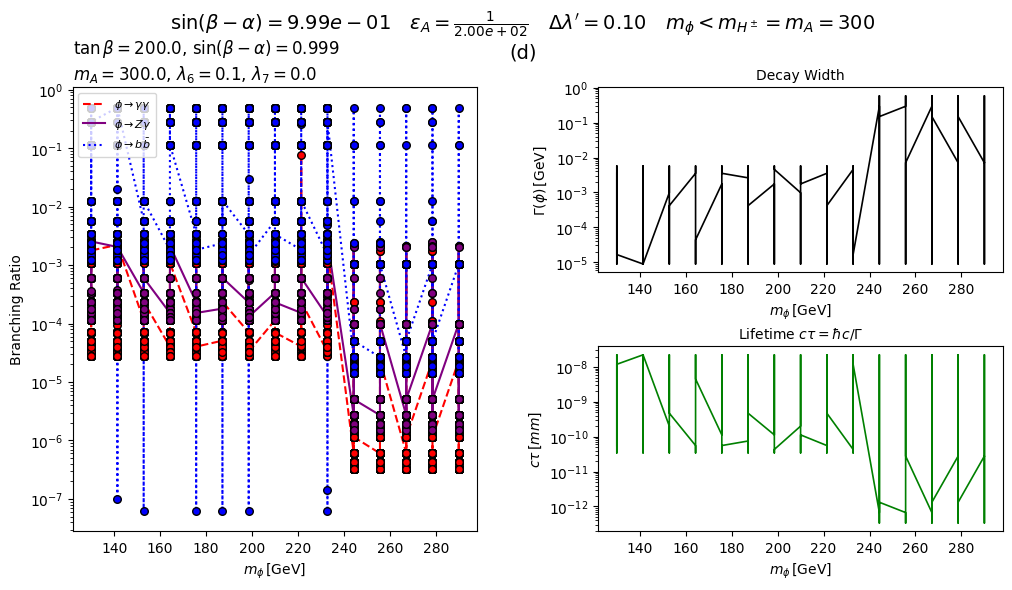

      📈 Ploteando tanβ=500.0 (N=2773)


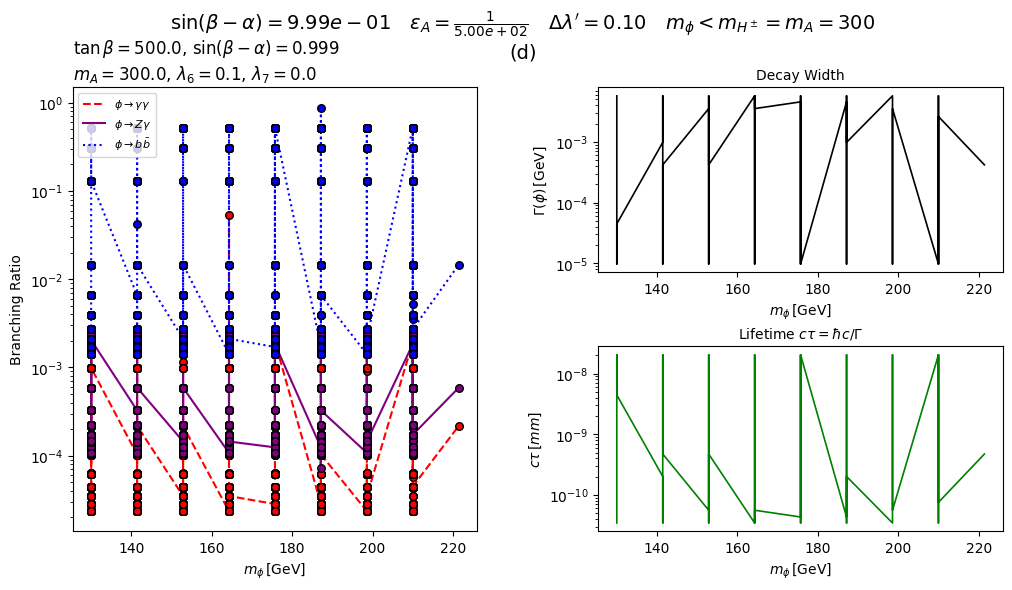

      📈 Ploteando tanβ=1000.0 (N=1390)


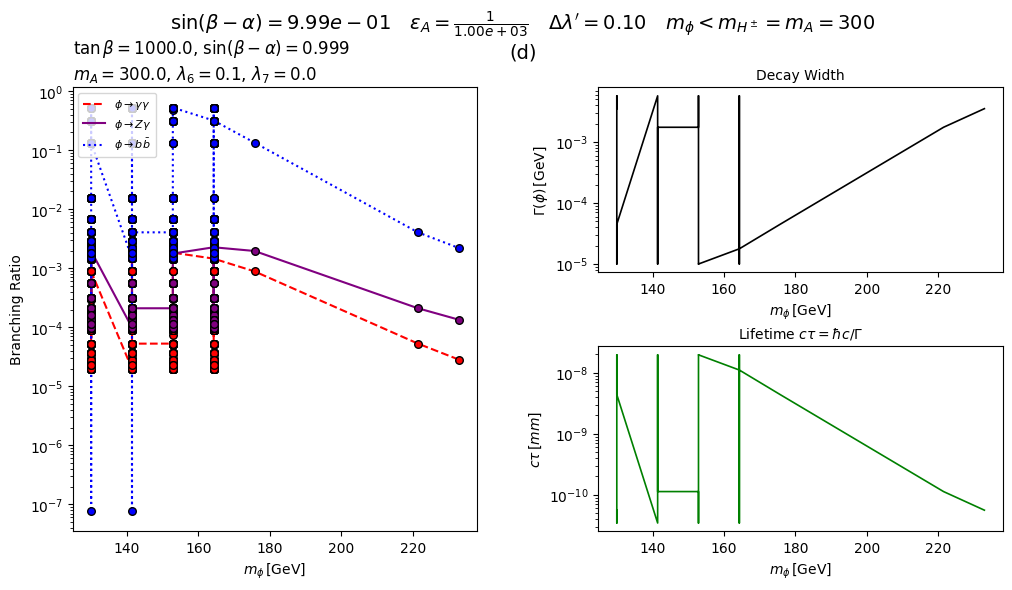

      📈 Ploteando tanβ=1500.0 (N=1046)


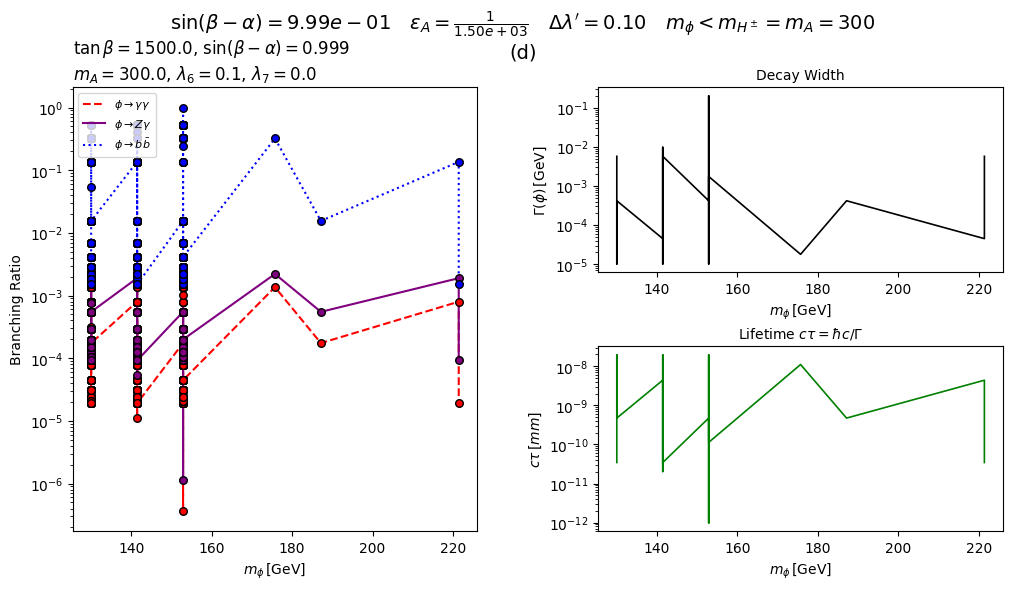

      📈 Ploteando tanβ=2000.0 (N=695)


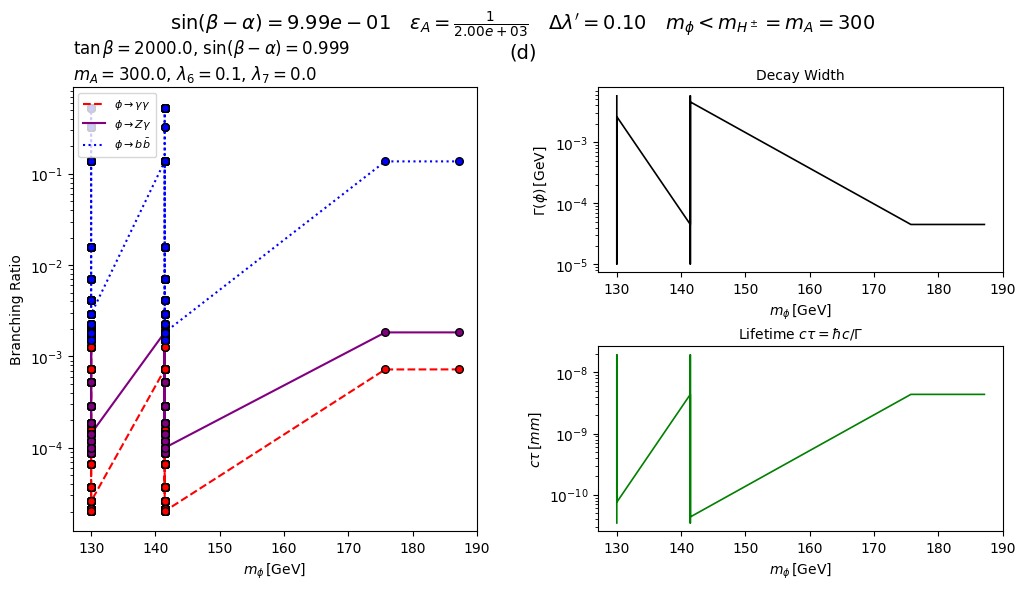

      📈 Ploteando tanβ=8000.0 (N=3815)


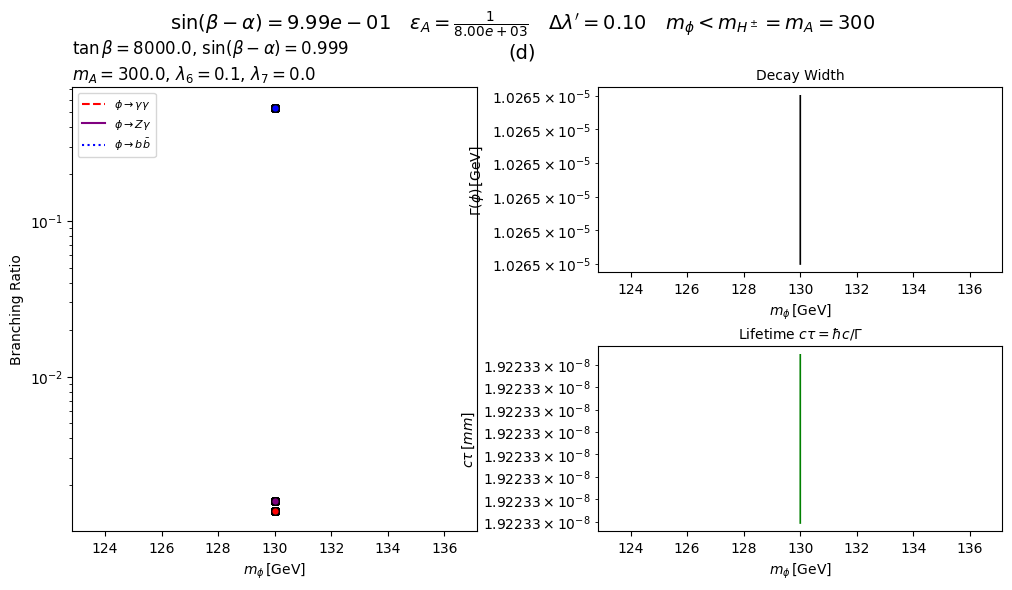

      📈 Ploteando tanβ=9000.0 (N=3811)


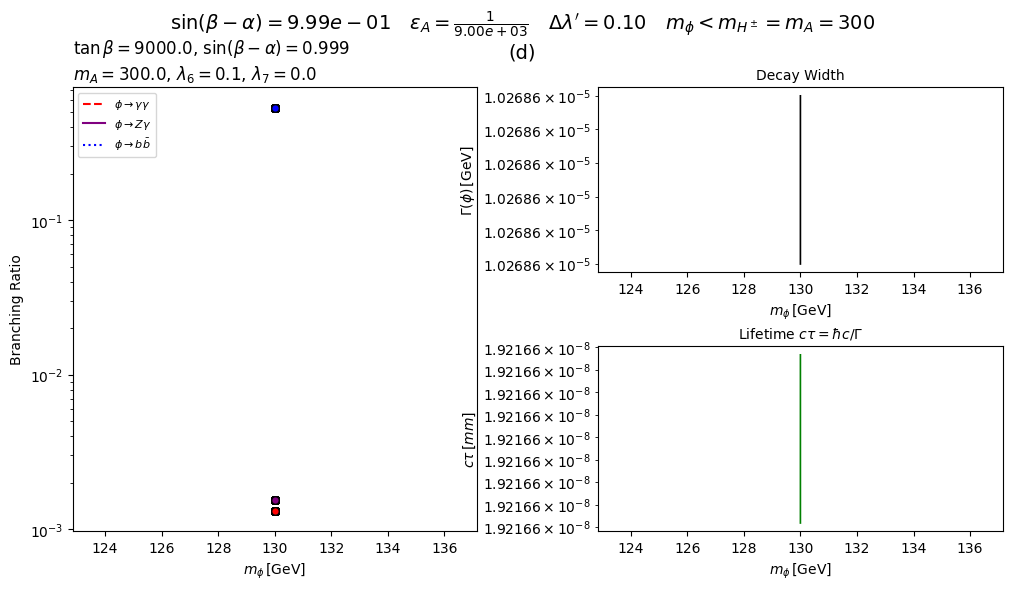

      📈 Ploteando tanβ=10000.0 (N=3808)


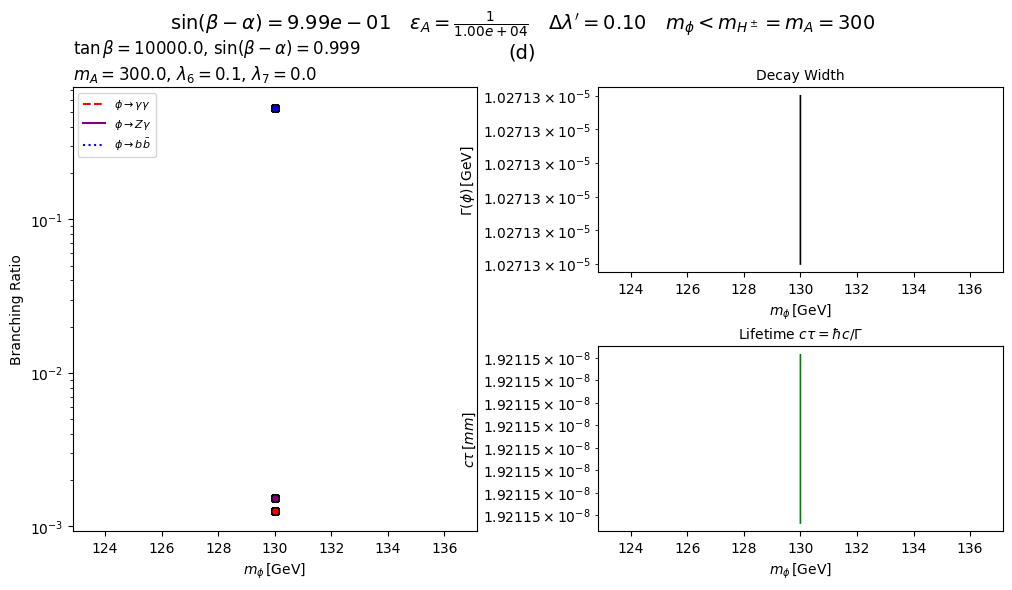

   👉 Analizando sin(b-a) = 0.9995
      📈 Ploteando tanβ=10000.0 (N=1739)


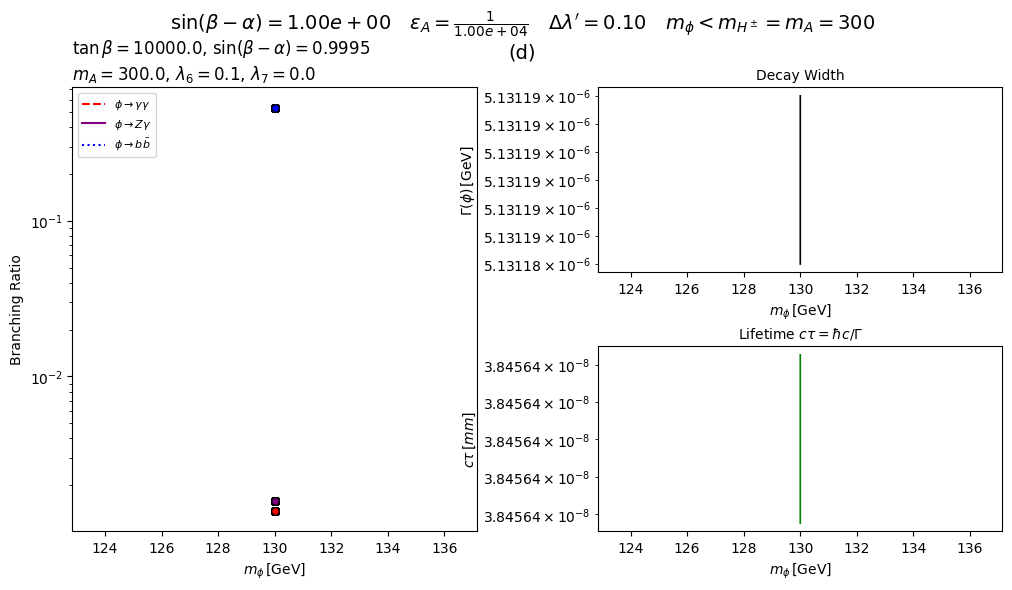

   👉 Analizando sin(b-a) = 0.9999
      📈 Ploteando tanβ=100.0 (N=26035)


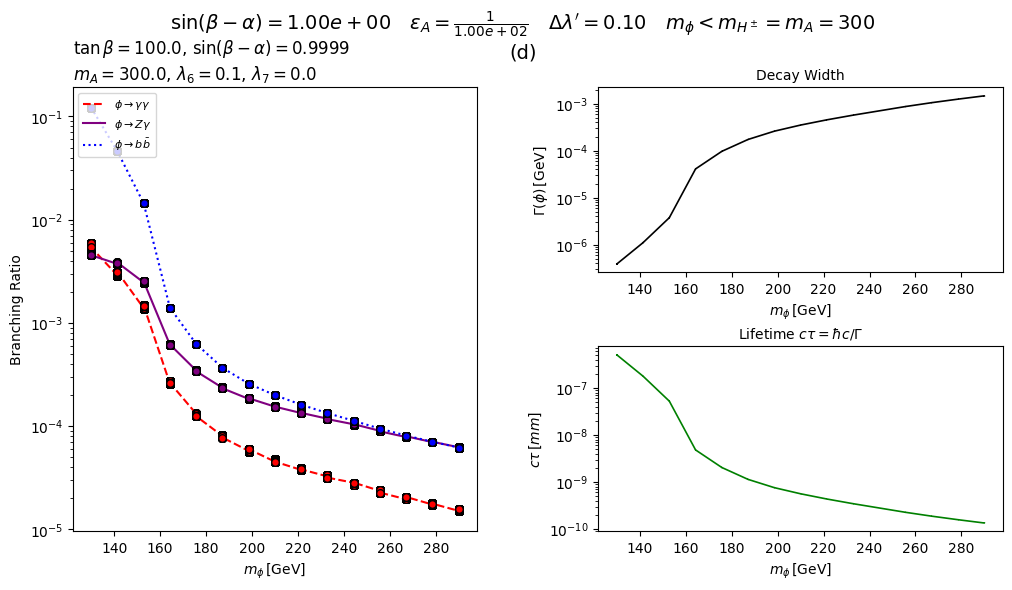

      📈 Ploteando tanβ=1000.0 (N=19166)


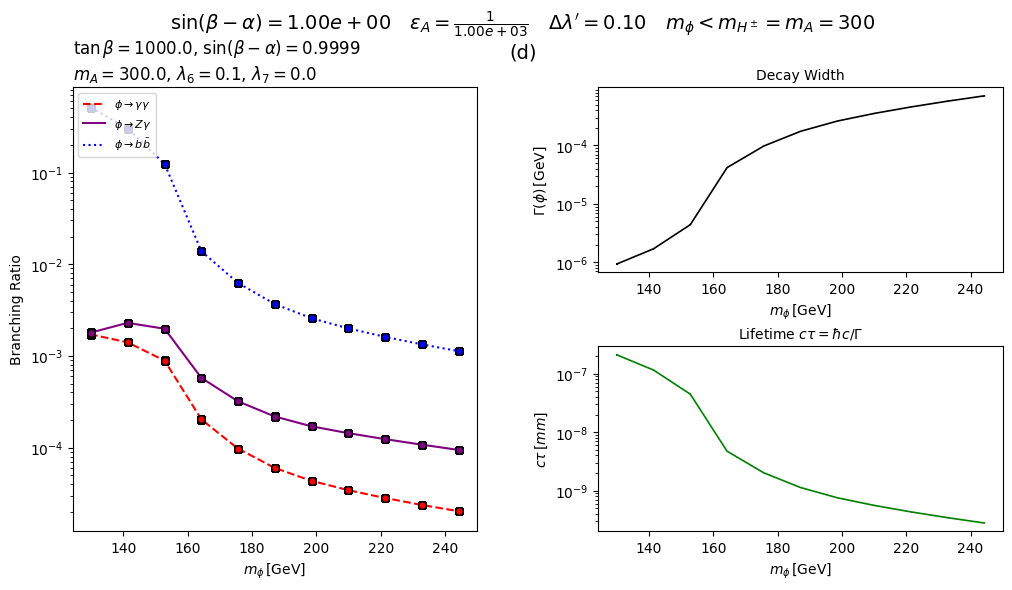

      📈 Ploteando tanβ=5000.0 (N=5229)


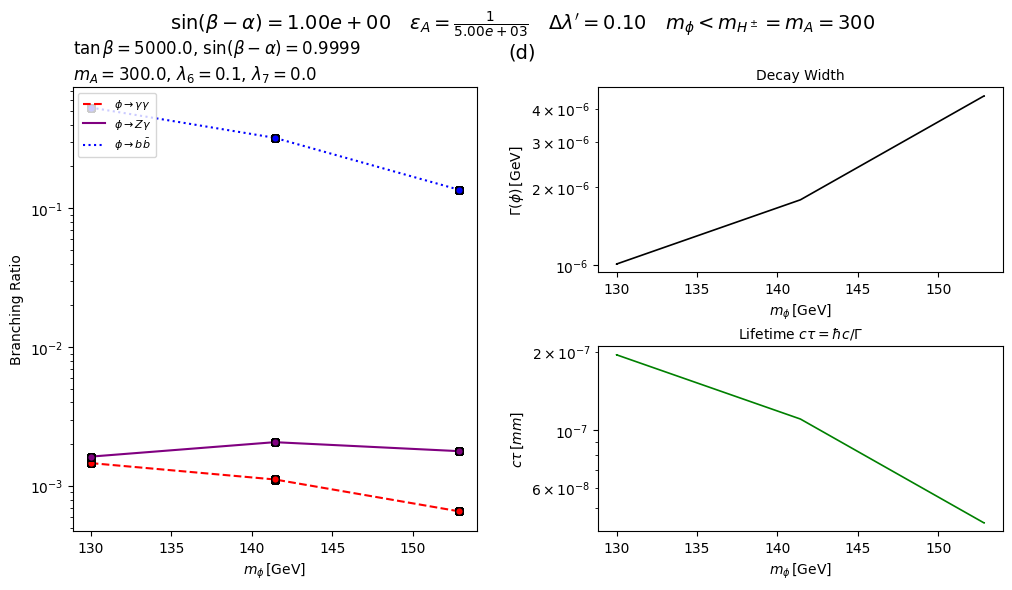

      📈 Ploteando tanβ=10000.0 (N=17436)


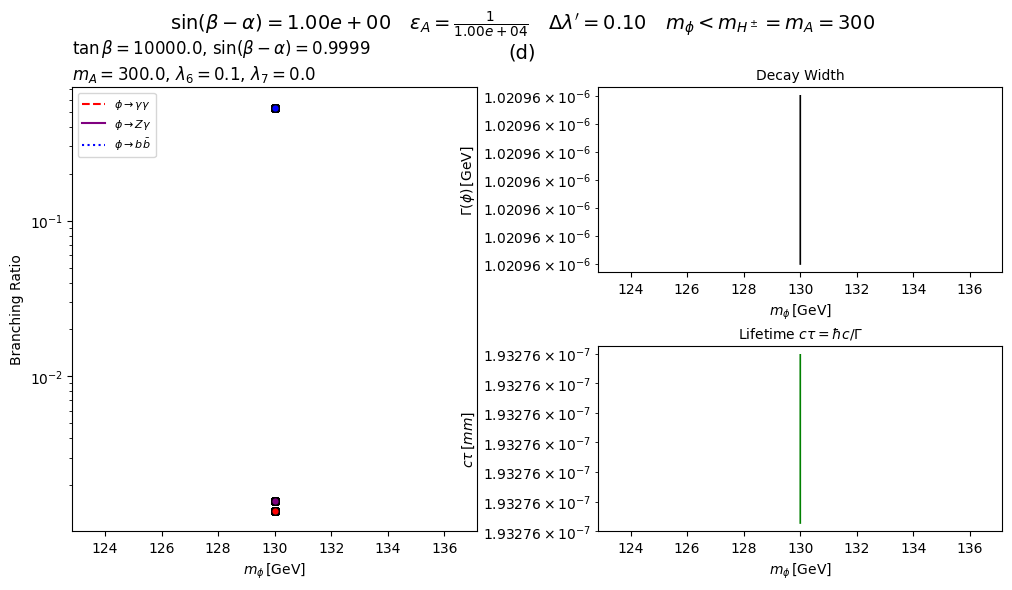

      📈 Ploteando tanβ=15000.0 (N=17442)


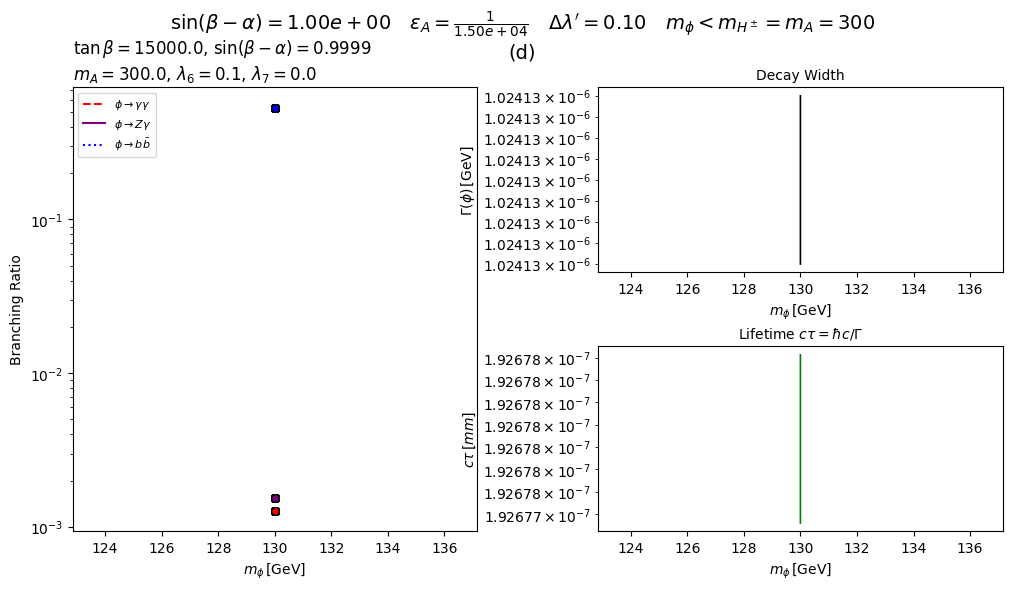

      📈 Ploteando tanβ=20000.0 (N=17444)


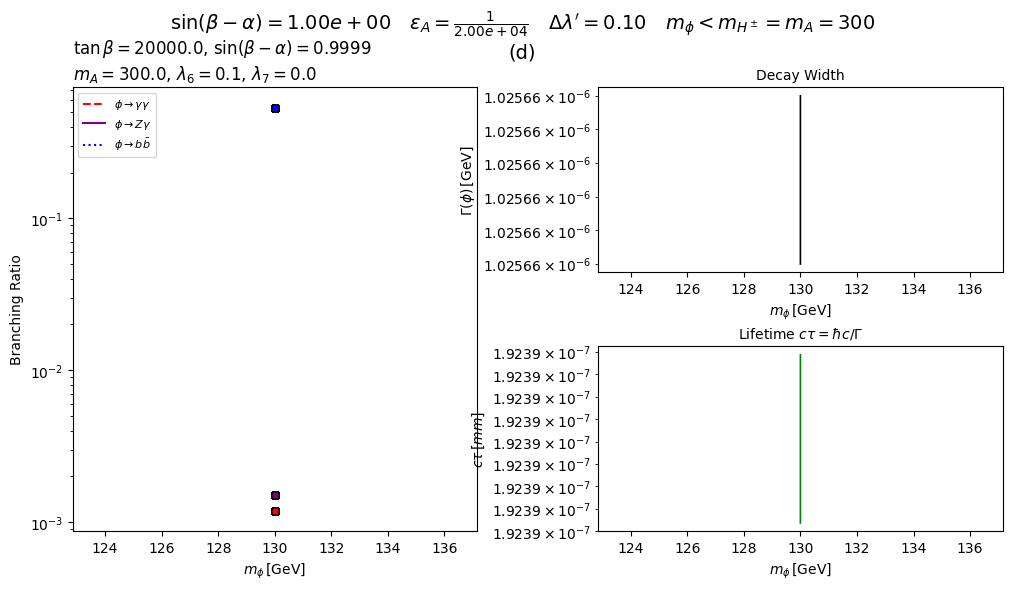


✅ Generación masiva completada.


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Asegúrate de que df_physical ya esté cargado y filtrado (positivity/unitarity/perturbativity OK)
# df_physical = ... 

# 1. Identificar parámetros únicos en el dataset
# Usamos .unique() y sorted() para tener un orden lógico
unique_mAs      = sorted(df_physical['mA'].unique())
unique_l6s      = sorted(df_physical['lambda6'].unique())
unique_l7s      = sorted(df_physical['lambda7'].unique())
unique_sin_bas  = sorted(df_physical['sin_ba'].unique())

print(f"🔍 Espacio de parámetros detectado:")
print(f"   mA:      {unique_mAs}")
print(f"   lambda6: {unique_l6s}")
print(f"   lambda7: {unique_l7s}")
print(f"   sin_ba:  {unique_sin_bas}")
print("-" * 50)

# Función auxiliar (la misma que tenías, ligeramente ajustada para recibir params explícitos)
def build_results_subset(subset, params_dict):
    """Construye la lista de diccionarios 'results' desde un subset ya filtrado."""
    subset = subset.sort_values(by='m_phi')
    results = []
    
    for _, row in subset.iterrows():
        total_w = row['total_width']
        if pd.isna(total_w) or total_w <= 0:
            br_Zga = None
            br_bb  = None
        else:
            br_Zga = row['width_Zga'] / total_w
            br_bb  = row['width_bb']  / total_w

        entry = {
            'mphi': float(row['m_phi']),
            'br': {
                'gaga': float(row['br_gaga']),
                'Zga':  float(br_Zga) if br_Zga is not None else 0.0,
                'bb':   float(br_bb)  if br_bb  is not None else 0.0
            },
            'total_width': float(total_w) if total_w is not None else 0.0,
            # Flags ya sabemos que son 1 porque usamos df_physical, pero los guardamos
            'flags': {
                'positivity': 1, 'unitarity': 1, 'perturbativity': 1
            },
            'params': {
                'mA':       params_dict['mA'],
                'm12':      float(row['m12']), # m12 varía punto a punto
                'lambda6':  params_dict['lambda6'],
                'lambda7':  params_dict['lambda7'],
                'sin_ba':   params_dict['sin_ba'],
                'tan_beta': params_dict['tan_beta']
            }
        }
        results.append(entry)
    return results

# 2. Bucle Maestro
# Itera sobre los escenarios de física fija (mA, l6, l7)
for ma_val in unique_mAs:
    for l6_val in unique_l6s:
        for l7_val in unique_l7s:
            
            # Máscara Base (Escenario Físico)
            mask_scenario = (
                (df_physical['mA'] == ma_val) &
                (df_physical['lambda6'] == l6_val) &
                (df_physical['lambda7'] == l7_val)
            )
            df_scenario = df_physical[mask_scenario]
            
            if df_scenario.empty:
                continue # Saltar escenarios sin datos

            print(f"\n📍 Escenario: mA={ma_val}, l6={l6_val}, l7={l7_val}")

            # 3. Iterar sobre sin_ba
            for sin_ba_val in unique_sin_bas:
                
                # Filtrar por sin_ba
                df_sin = df_scenario[df_scenario['sin_ba'] == sin_ba_val]
                
                if df_sin.empty:
                    continue

                print(f"   👉 Analizando sin(b-a) = {sin_ba_val}")

                # 4. Iterar sobre tan_beta (solo los presentes en este subset)
                current_tan_betas = sorted(df_sin['tan_beta'].unique())
                
                for tb_val in current_tan_betas:
                    # Subset final para el plot
                    df_final = df_sin[df_sin['tan_beta'] == tb_val]
                    
                    if len(df_final) < 5: 
                        # Opcional: Saltar si hay muy pocos puntos para hacer una curva decente
                        print(f"      [SKIP] tanβ={tb_val} (Solo {len(df_final)} puntos)")
                        continue

                    # Construir estructura de datos para el plotter
                    params_dict = {
                        'mA': ma_val, 'lambda6': l6_val, 'lambda7': l7_val,
                        'sin_ba': sin_ba_val, 'tan_beta': tb_val
                    }
                    results_tb = build_results_subset(df_final, params_dict)

                    # Generar Título Dinámico
                    plot_title = (
                        fr"$\tan\beta={tb_val}$, $\sin(\beta-\alpha)={sin_ba_val}$"
                        "\n"
                        fr"$m_A={ma_val}$, $\lambda_6={l6_val}$, $\lambda_7={l7_val}$"
                    )

                    print(f"      📈 Ploteando tanβ={tb_val} (N={len(results_tb)})")
                    
                    try:
                        # Llamada a tu librería gráfica
                        plot_branchings_and_lifetime(
                            results_tb,
                            subplot_tag=plot_title,
                            lifetime_unit="mm",
                            lifetime_log=True,
                            width_log=True,
                            br_log=True
                        )
                        
                        # Opcional: Guardar automáticamente
                        # filename = f"plot_mA{ma_val}_sba{sin_ba_val}_tb{tb_val}.png"
                        # plt.savefig(os.path.join("plots", filename))
                        # plt.close() # Importante para liberar memoria en loops largos
                        
                    except Exception as e:
                        print(f"      ❌ Error ploteando: {e}")

print("\n✅ Generación masiva completada.")

Incorporando distintos puntos superpuestos

🧪 Generando datos sintéticos para probar el plotter...


/tmp/ipykernel_69786/185795907.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


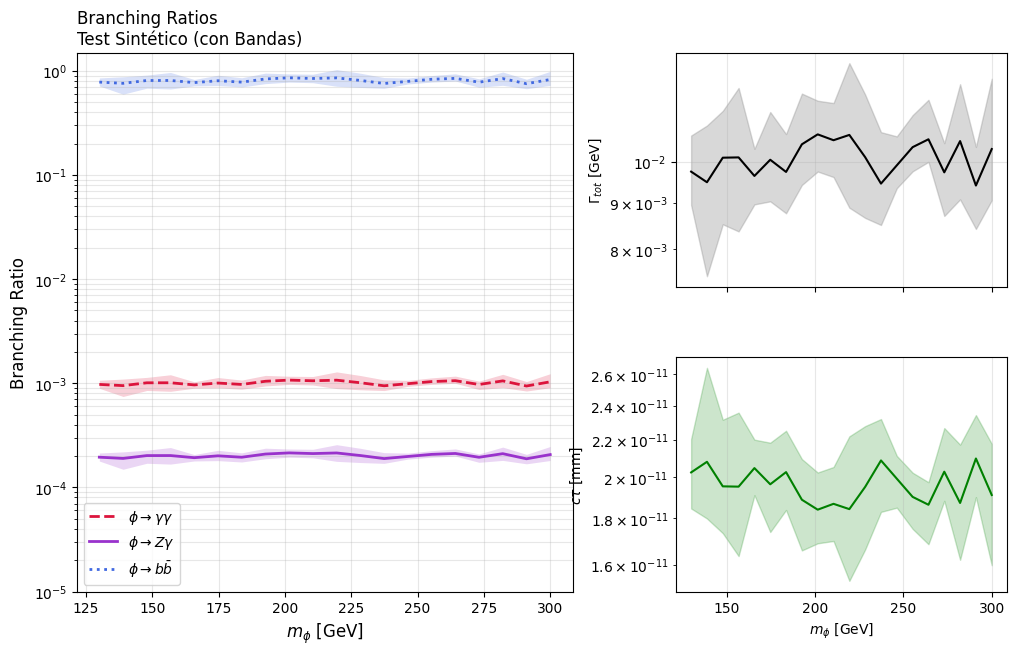

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.interpolate import interp1d

# === NUEVA FUNCIÓN OPTIMIZADA ===
def plot_branchings_with_bands(
    results: list,
    subplot_tag: str = "",
    lifetime_unit: str = "mm",
    use_bands: bool = True, # Nuevo switch: Bandas vs Scatter
    smooth_factor: float = 0.0 # Suavizado (0 = crudo)
):
    """
    Versión avanzada de plot_branchings que detecta superposiciones y las convierte
    en bandas de confianza visuales (min-max envelope).
    """
    
    # 1. Extracción y Limpieza de Datos
    # Convertimos la lista de dicts en arrays estructurados para operar rápido
    mphi_raw = np.array([r['mphi'] for r in results])
    
    # Extraemos canales
    channels = ['gaga', 'Zga', 'bb']
    data = {ch: np.array([r['br'][ch] for r in results]) for ch in channels}
    total_width = np.array([r['total_width'] for r in results])
    
    # Filtramos solo puntos físicos (Unitarity+Positivity+Perturbativity OK)
    valid_mask = np.array([
        all(r['flags'][f] == 1 for f in ['positivity', 'unitarity', 'perturbativity'])
        for r in results
    ])
    
    if not any(valid_mask):
        print(f"⚠️ [Plotter] No hay puntos físicos válidos para {subplot_tag}. Saltando.")
        return

    mphi_phys = mphi_raw[valid_mask]
    data_phys = {ch: vals[valid_mask] for ch, vals in data.items()}
    width_phys = total_width[valid_mask]
    
    # 2. Procesamiento de Bandas (Binning)
    # Si tenemos múltiples puntos para el mismo m_phi (o muy cercanos), creamos bandas.
    # Usamos np.unique para encontrar las masas discretas
    unique_masses = np.unique(mphi_phys)
    
    stats = {ch: {'mean': [], 'min': [], 'max': []} for ch in channels}
    width_stats = {'mean': [], 'min': [], 'max': []}
    
    for m in unique_masses:
        # Máscara para esta masa específica
        mask_m = (mphi_phys == m)
        
        # Branching Ratios
        for ch in channels:
            vals = data_phys[ch][mask_m]
            stats[ch]['mean'].append(np.mean(vals))
            stats[ch]['min'].append(np.min(vals))
            stats[ch]['max'].append(np.max(vals))
            
        # Decay Width
        w_vals = width_phys[mask_m]
        width_stats['mean'].append(np.mean(w_vals))
        width_stats['min'].append(np.min(w_vals))
        width_stats['max'].append(np.max(w_vals))

    # Convertir listas a arrays
    for ch in channels:
        for k in stats[ch]: stats[ch][k] = np.array(stats[ch][k])
    for k in width_stats: width_stats[k] = np.array(width_stats[k])

    # 3. Configuración del Plot
    fig = plt.figure(figsize=(12, 7))
    gs = GridSpec(2, 2, figure=fig, width_ratios=[1.2, 0.8], wspace=0.25, hspace=0.3)
    
    # --- PANEL A: Branching Ratios (Izquierda, Grande) ---
    ax_br = fig.add_subplot(gs[:, 0])
    
    colors = {'gaga': 'crimson', 'Zga': 'darkorchid', 'bb': 'royalblue'}
    styles = {'gaga': '--', 'Zga': '-', 'bb': ':'}
    labels = {
        'gaga': r'$\phi \to \gamma\gamma$', 
        'Zga': r'$\phi \to Z\gamma$', 
        'bb': r'$\phi \to b\bar{b}$'
    }

    for ch in channels:
        # Linea central
        ax_br.plot(unique_masses, stats[ch]['mean'], 
                  color=colors[ch], linestyle=styles[ch], linewidth=2, 
                  label=labels[ch])
        
        # Banda (Relleno)
        # Solo dibujamos banda si hay diferencia real entre min y max
        if use_bands and np.any(stats[ch]['max'] - stats[ch]['min'] > 1e-5):
            ax_br.fill_between(unique_masses, stats[ch]['min'], stats[ch]['max'],
                              color=colors[ch], alpha=0.2, linewidth=0)
            
    ax_br.set_xlabel(r'$m_\phi$ [GeV]', fontsize=12)
    ax_br.set_ylabel('Branching Ratio', fontsize=12)
    ax_br.set_yscale('log')
    ax_br.set_ylim(1e-5, 1.5) # Ajuste dinámico usual
    ax_br.grid(True, which="both", alpha=0.3)
    ax_br.legend(loc='lower left', fontsize=10, frameon=True)
    ax_br.set_title(f"Branching Ratios\n{subplot_tag}", loc='left')

    # --- PANEL B: Decay Width (Arriba Derecha) ---
    ax_w = fig.add_subplot(gs[0, 1])
    
    # Banda para el ancho
    ax_w.plot(unique_masses, width_stats['mean'], 'k-', lw=1.5)
    if use_bands:
        ax_w.fill_between(unique_masses, width_stats['min'], width_stats['max'], color='gray', alpha=0.3)
        
    ax_w.set_ylabel(r'$\Gamma_{tot}$ [GeV]')
    ax_w.set_yscale('log')
    ax_w.grid(True, alpha=0.3)
    ax_w.set_xticklabels([]) # Ocultar x-labels para compartir eje visualmente

    # --- PANEL C: Lifetime (Abajo Derecha) ---
    ax_tau = fig.add_subplot(gs[1, 1])
    
    # Cálculo de ctau (hbar*c / Gamma)
    # Cuidado: operamos sobre los arrays de stats directamente (1/mean != mean(1/x), pero para plots visuales es aceptable si la varianza es baja)
    # Mejor: calcular min/max ctau basados en max/min Gamma
    hbar_c = 1.973e-13 # GeV * mm (aprox) -> Ajustar valor preciso
    hbar_c_preciso = 1.973269804e-13 # GeV mm
    
    ctau_mean = hbar_c_preciso / width_stats['mean']
    ctau_min  = hbar_c_preciso / width_stats['max'] # Gamma grande -> tau chico
    ctau_max  = hbar_c_preciso / width_stats['min']

    # Ajuste unidades
    scale = 1.0 if lifetime_unit == "mm" else 0.1 # cm
    
    ax_tau.plot(unique_masses, ctau_mean * scale, 'g-', lw=1.5)
    if use_bands:
        ax_tau.fill_between(unique_masses, ctau_min * scale, ctau_max * scale, color='green', alpha=0.2)
        
    ax_tau.set_ylabel(rf'$c\tau$ [{lifetime_unit}]')
    ax_tau.set_xlabel(r'$m_\phi$ [GeV]')
    ax_tau.set_yscale('log')
    ax_tau.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- PRUEBA RÁPIDA (Test Driver) ---
# Simular datos con ruido para probar las bandas
print("🧪 Generando datos sintéticos para probar el plotter...")
dummy_results = []
for m in np.linspace(130, 300, 20):
    for i in range(5): # 5 puntos por masa para simular superposición
        noise = np.random.normal(1, 0.1) # 10% de ruido
        dummy_results.append({
            'mphi': m,
            'br': {
                'gaga': 1e-3 * noise,
                'Zga': 1e-4 * noise * 2,
                'bb': 0.8 * noise
            },
            'total_width': 0.01 * noise,
            'flags': {'positivity': 1, 'unitarity': 1, 'perturbativity': 1},
            'params': {} # Dummy
        })

plot_branchings_with_bands(dummy_results, subplot_tag="Test Sintético (con Bandas)")

<>:173: SyntaxWarning: invalid escape sequence '\l'
<>:173: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_69786/579126438.py:173: SyntaxWarning: invalid escape sequence '\l'
  f"\n$m_A={ma:.0f}$ GeV, $\lambda_6={l6}$")


🔍 Espacio de parámetros detectado: 1 mA, 5 sin(b-a)

📍 Escenario: mA=300.0, l6=0.1
   👉 sin(b-a)=0.99
      📈 Ploteando tanβ=10.0 (N=62420)


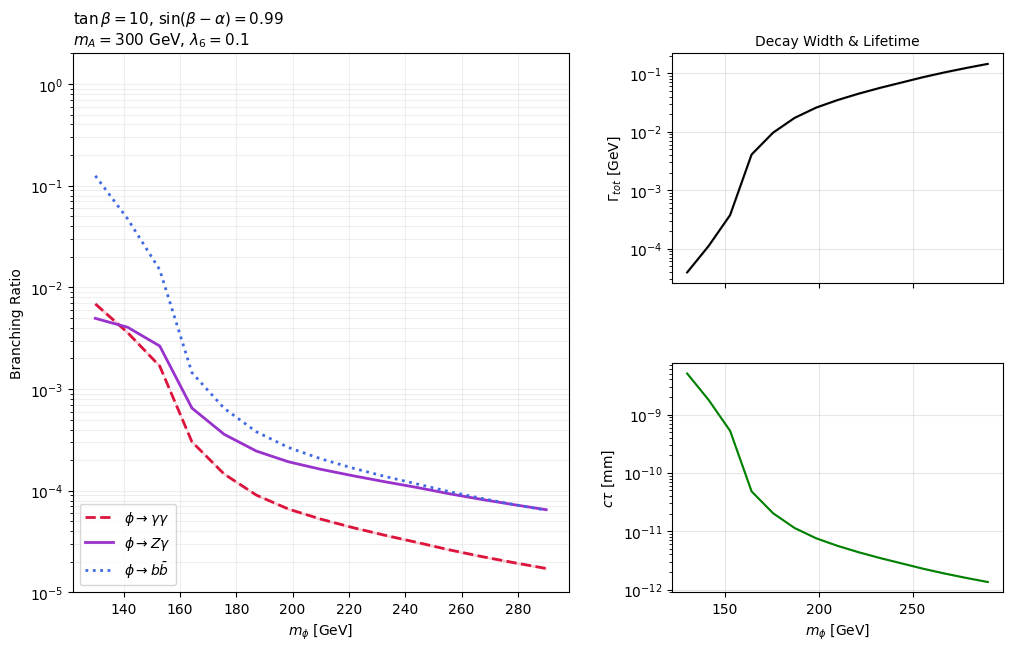

      📈 Ploteando tanβ=50.0 (N=10341)


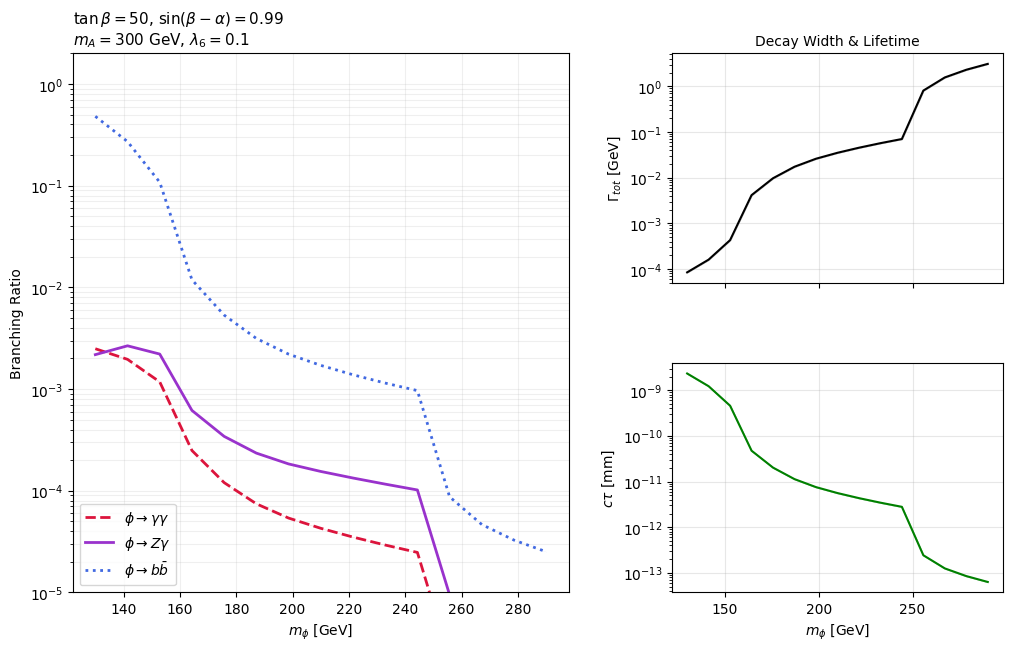

      📈 Ploteando tanβ=100.0 (N=8148)


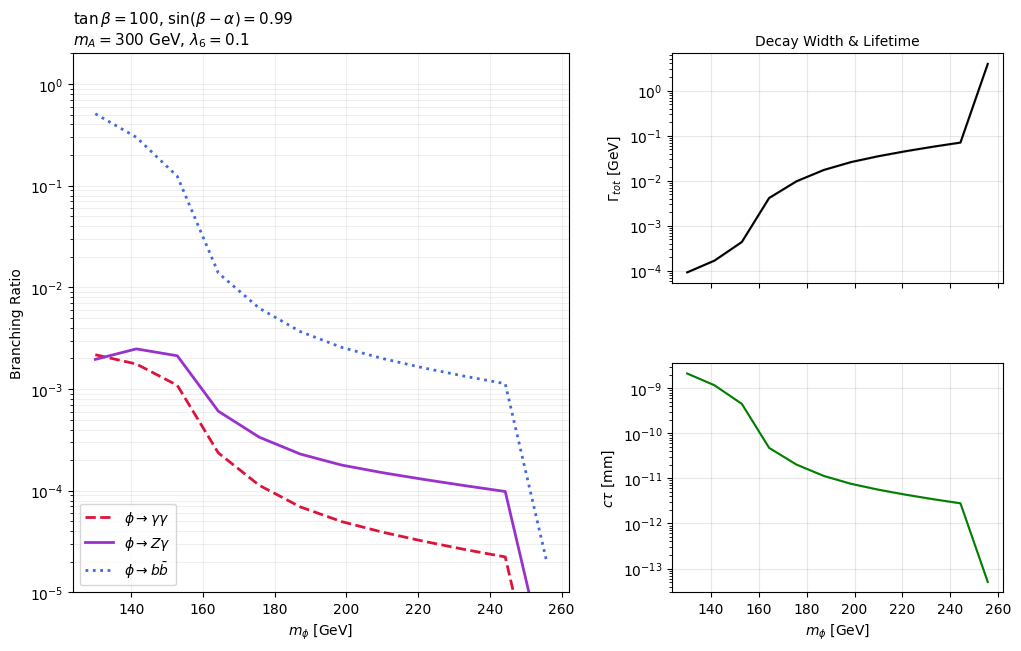

      📈 Ploteando tanβ=200.0 (N=4095)


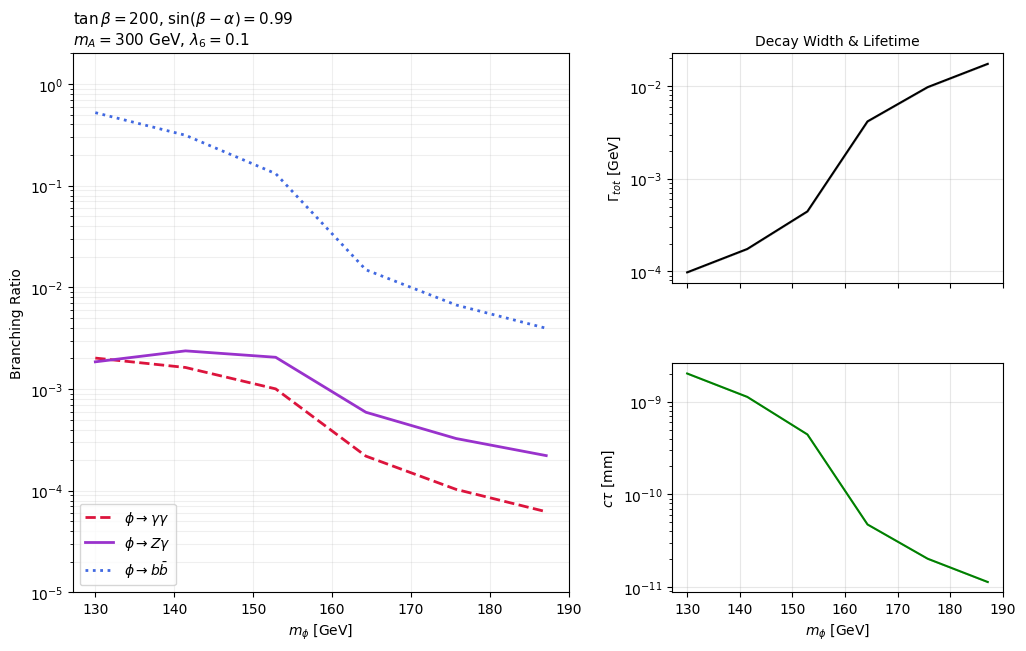

      📈 Ploteando tanβ=500.0 (N=2036)


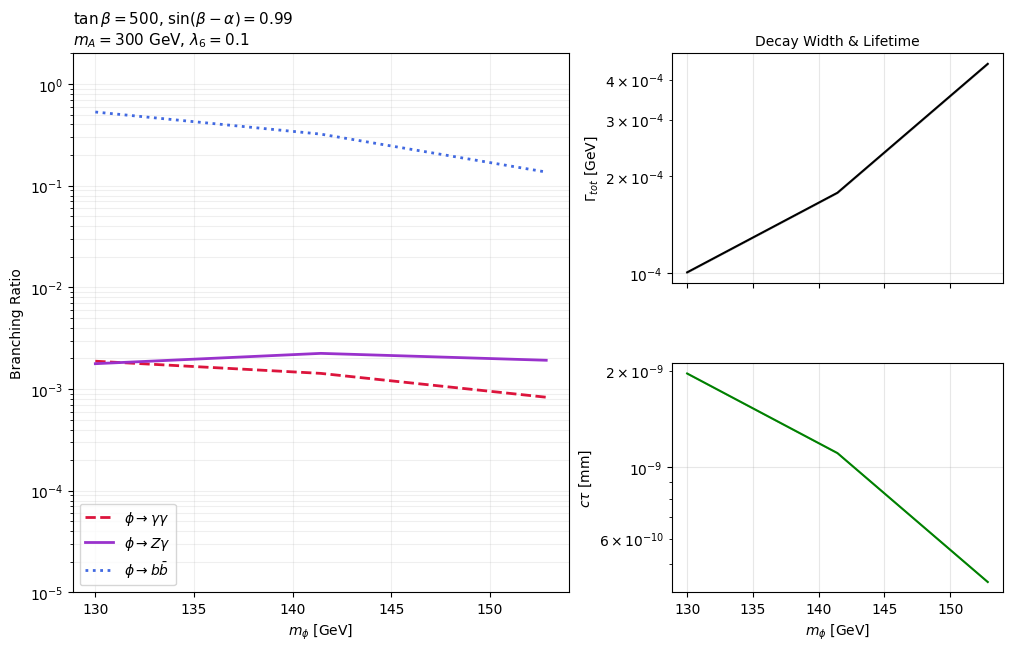

      📈 Ploteando tanβ=1000.0 (N=1344)


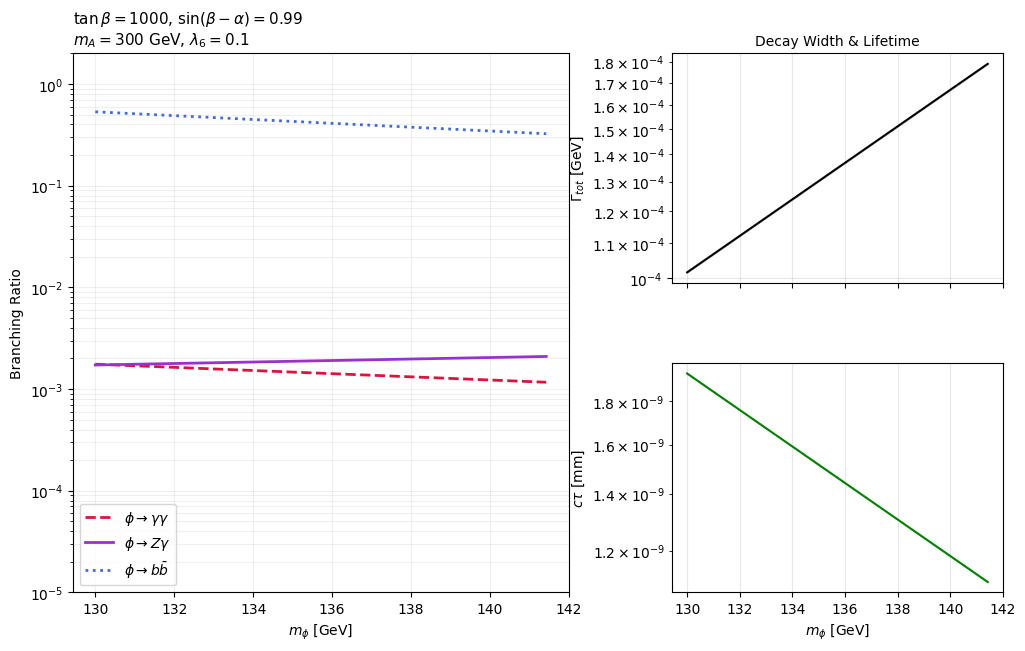

      📈 Ploteando tanβ=1500.0 (N=686)


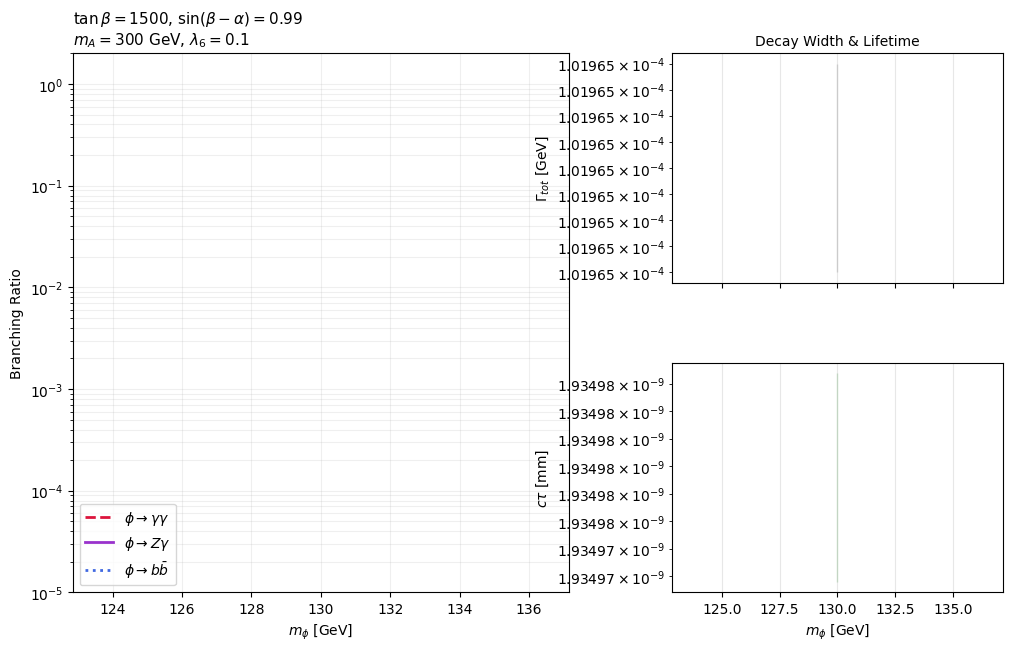

      📈 Ploteando tanβ=2000.0 (N=676)


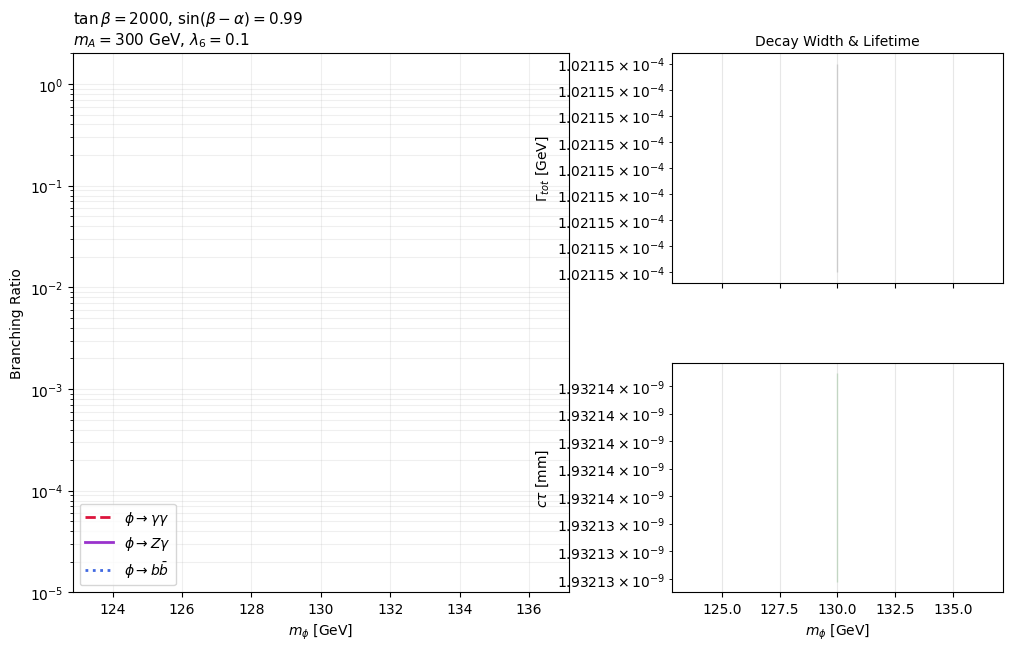

   👉 sin(b-a)=0.995
      📈 Ploteando tanβ=100.0 (N=10326)


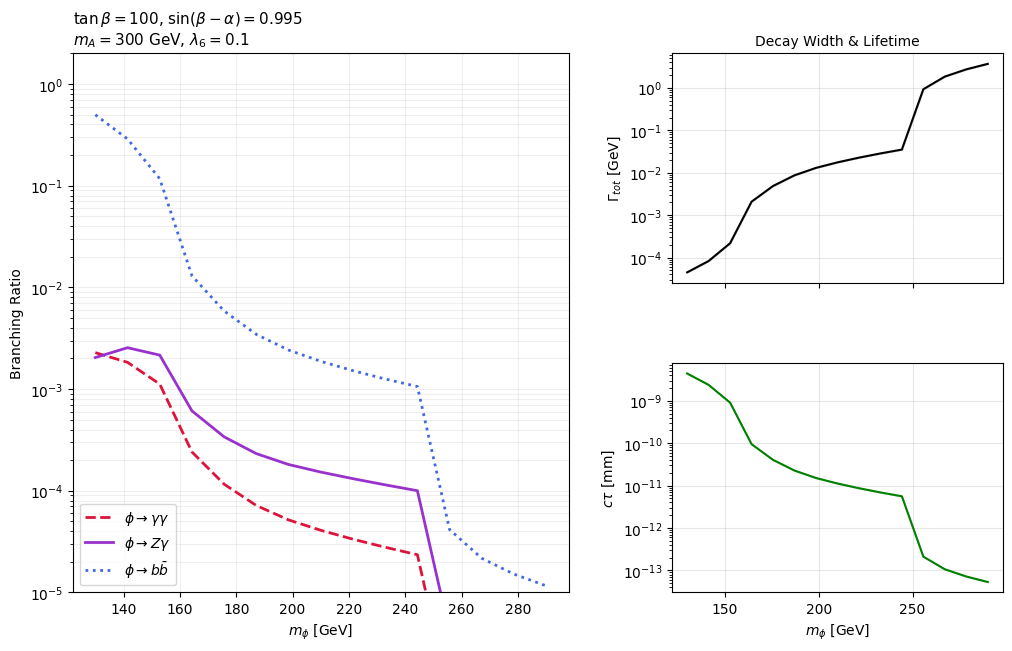

      📈 Ploteando tanβ=200.0 (N=6182)


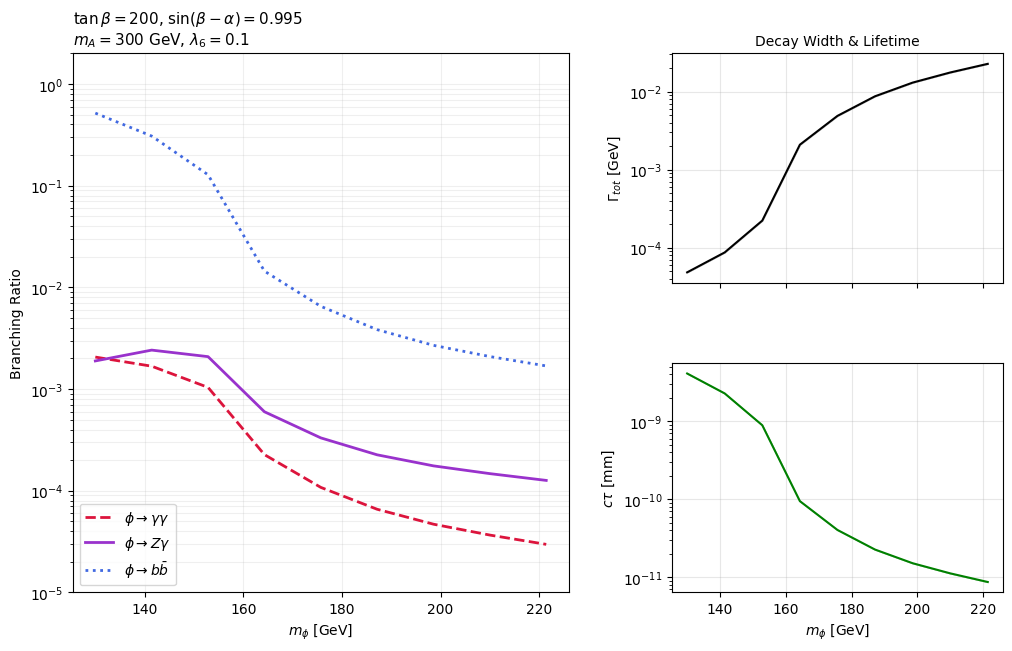

      📈 Ploteando tanβ=500.0 (N=2750)


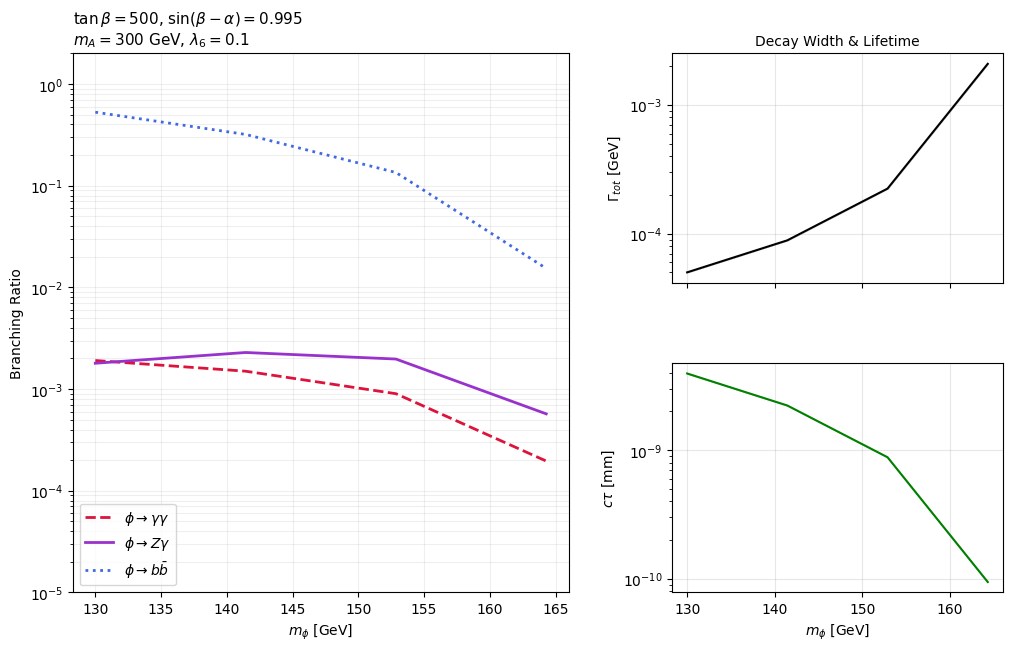

      📈 Ploteando tanβ=1000.0 (N=1378)


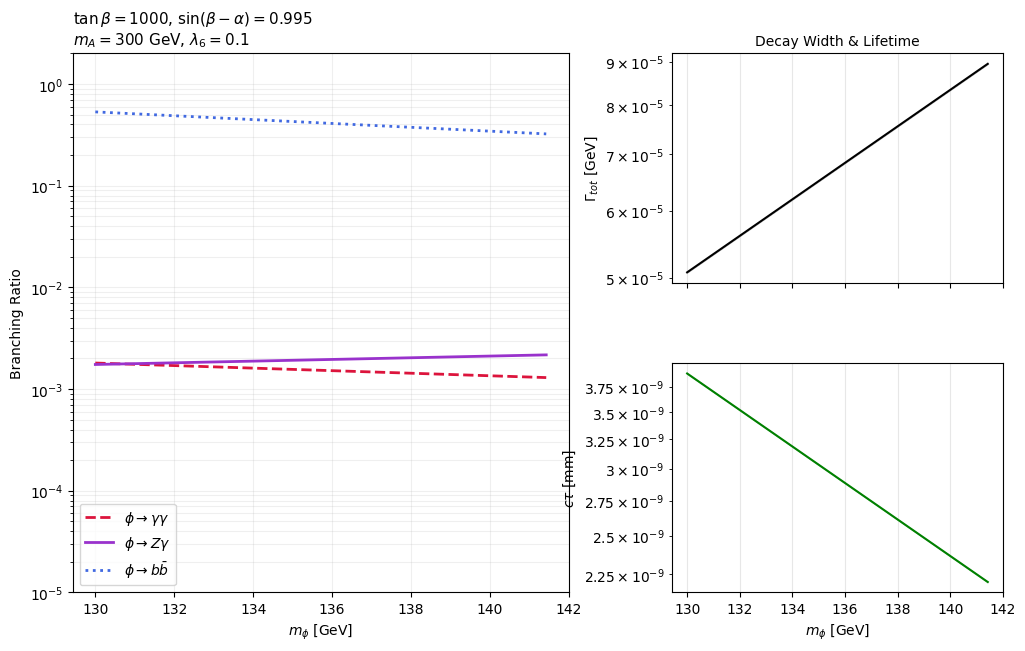

      📈 Ploteando tanβ=3000.0 (N=6844)


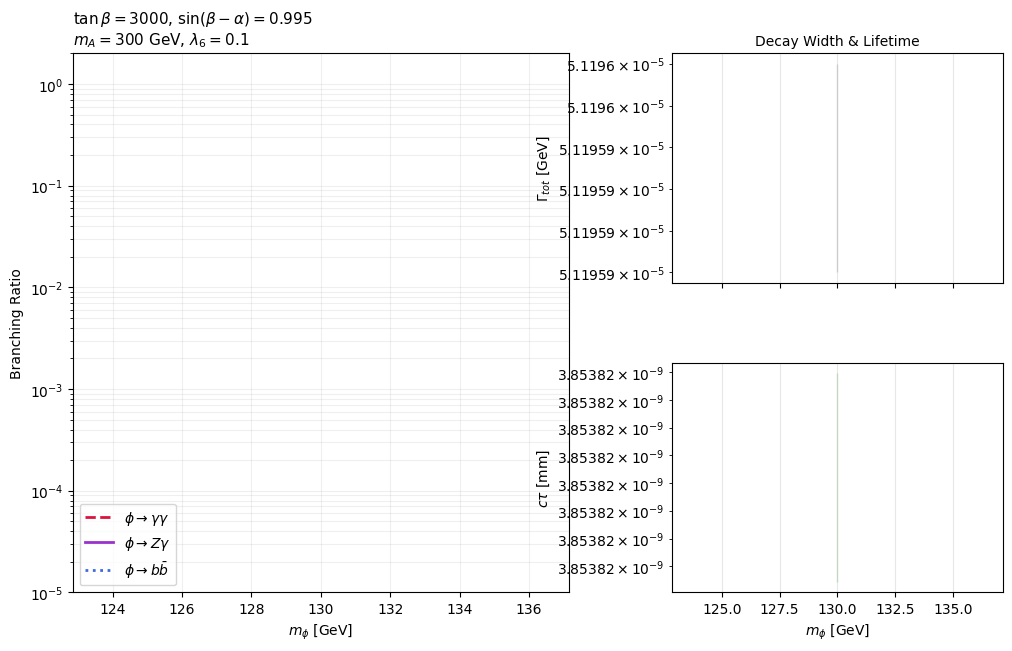

   👉 sin(b-a)=0.999
      📈 Ploteando tanβ=10.0 (N=5241)


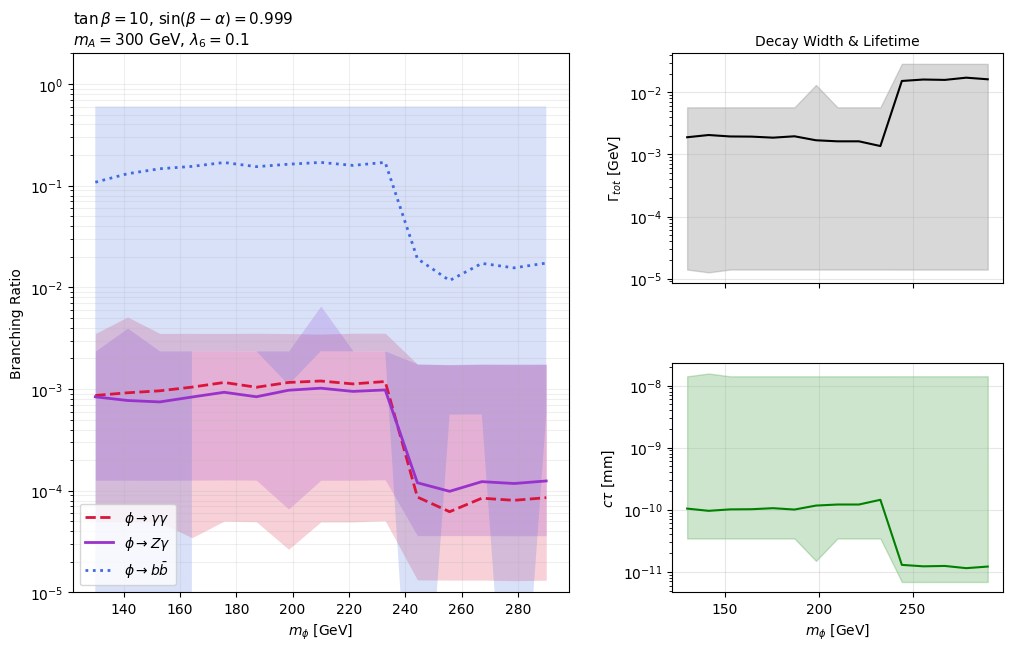

      📈 Ploteando tanβ=50.0 (N=5201)


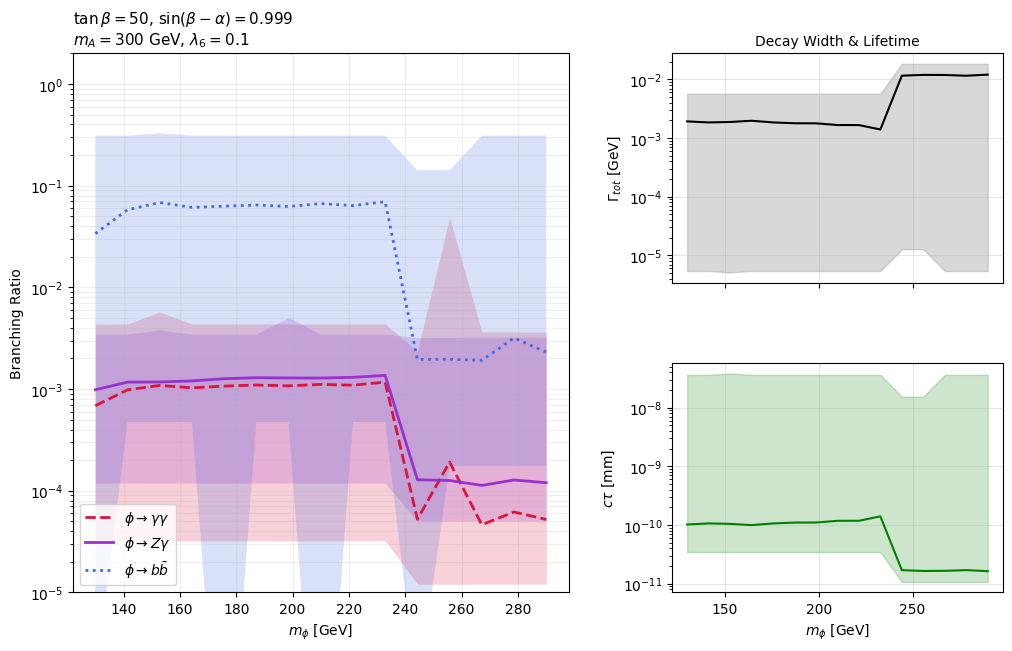

      📈 Ploteando tanβ=100.0 (N=5211)


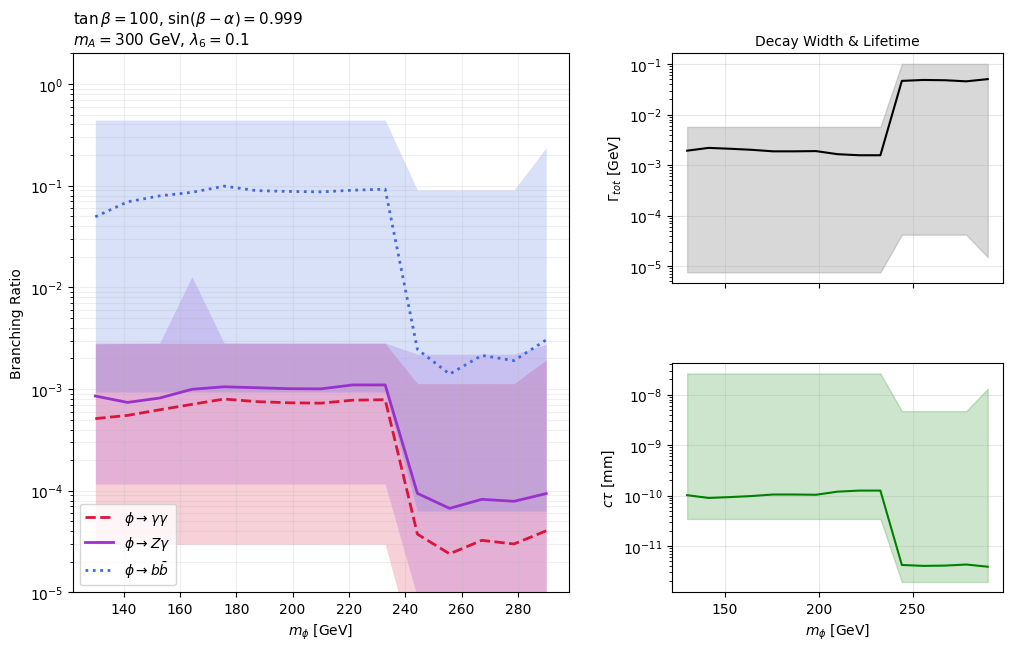

      📈 Ploteando tanβ=200.0 (N=5210)


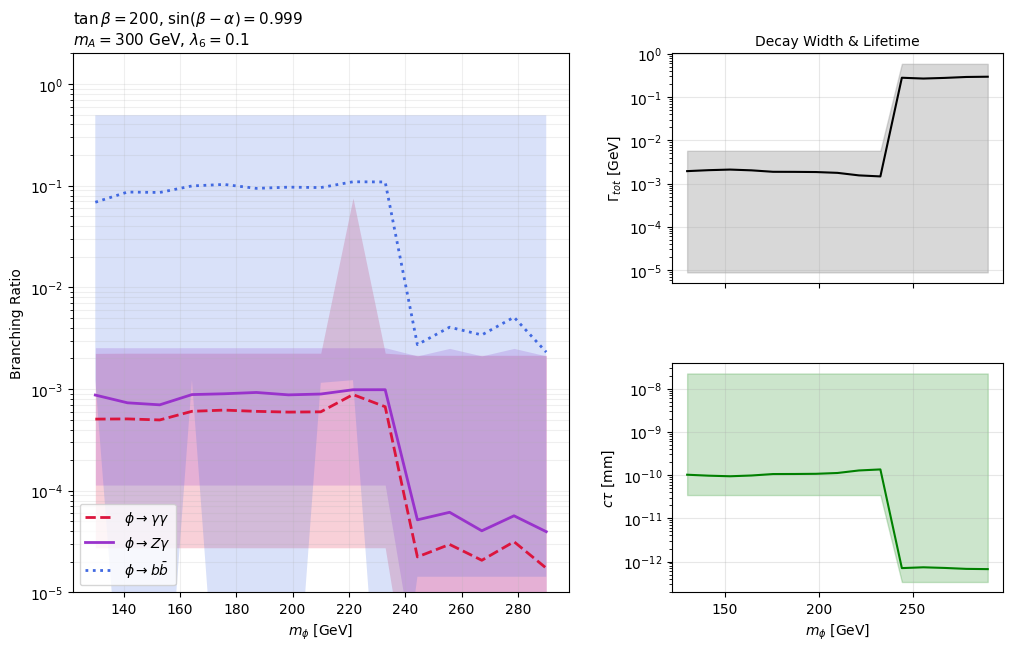

      📈 Ploteando tanβ=500.0 (N=2773)


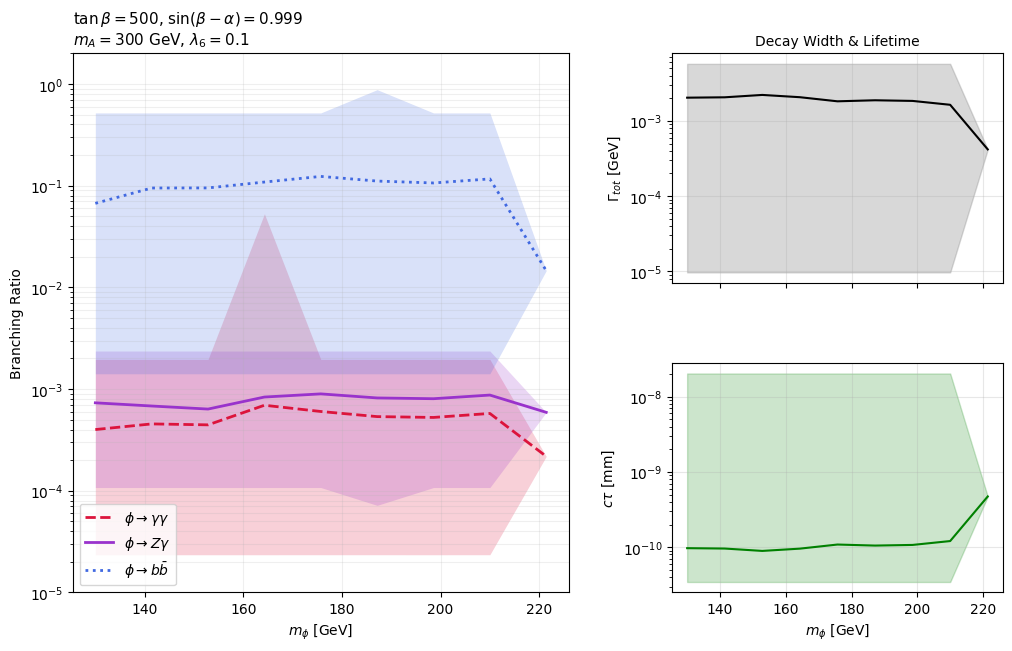

      📈 Ploteando tanβ=1000.0 (N=1390)


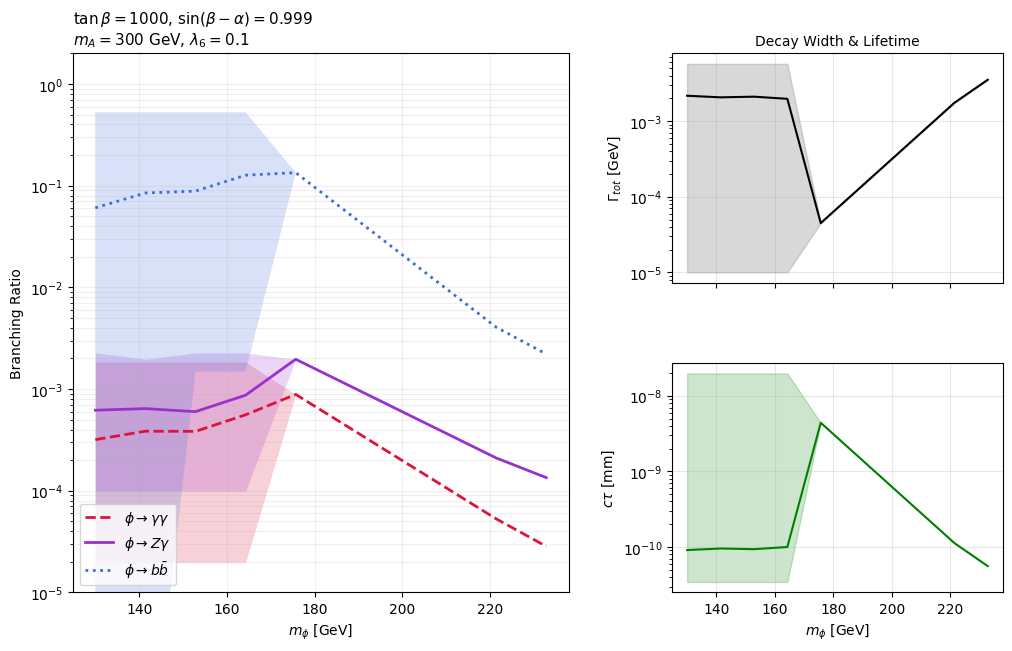

      📈 Ploteando tanβ=1500.0 (N=1046)


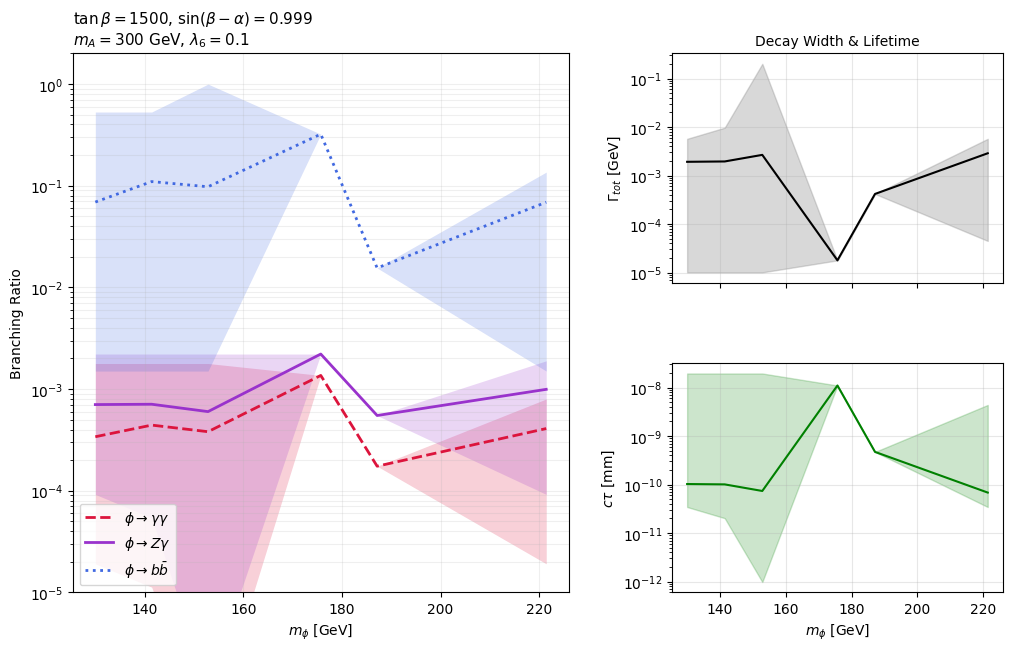

      📈 Ploteando tanβ=2000.0 (N=695)


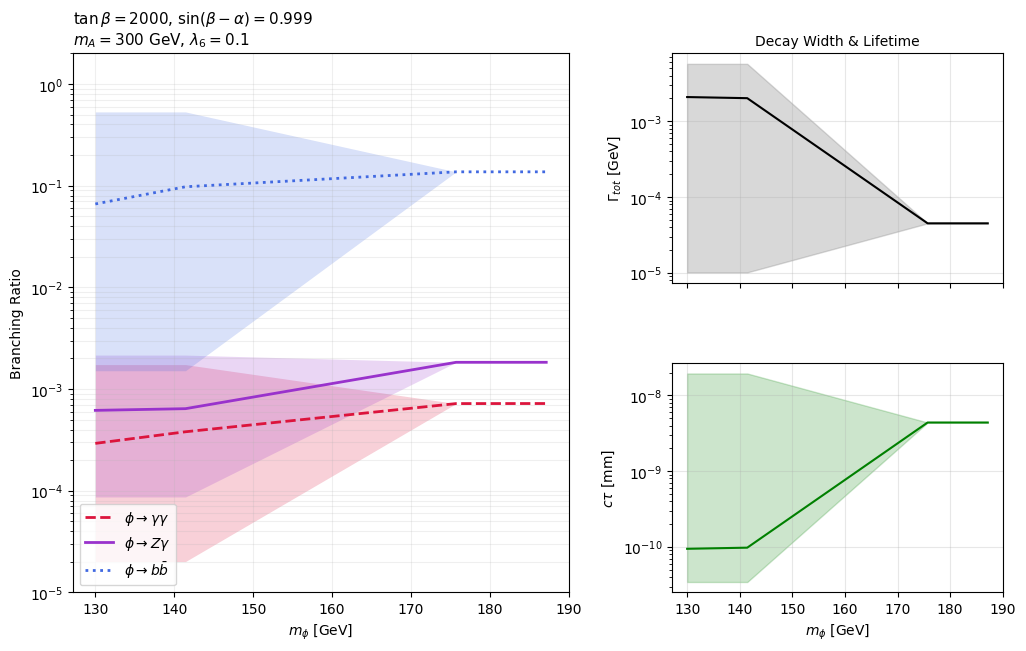

      📈 Ploteando tanβ=8000.0 (N=3815)


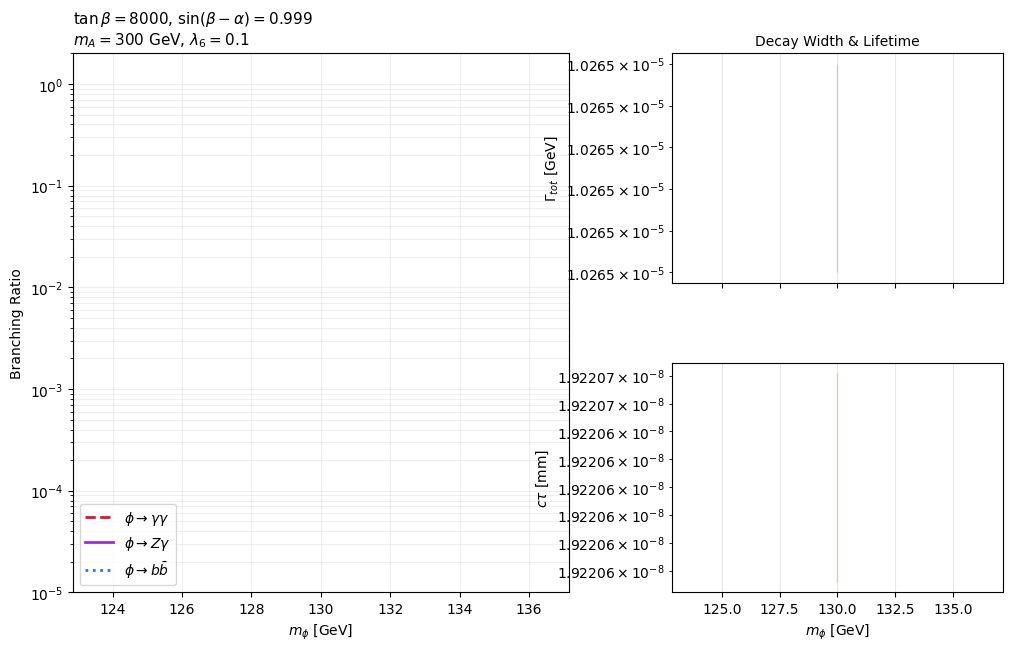

      📈 Ploteando tanβ=9000.0 (N=3811)


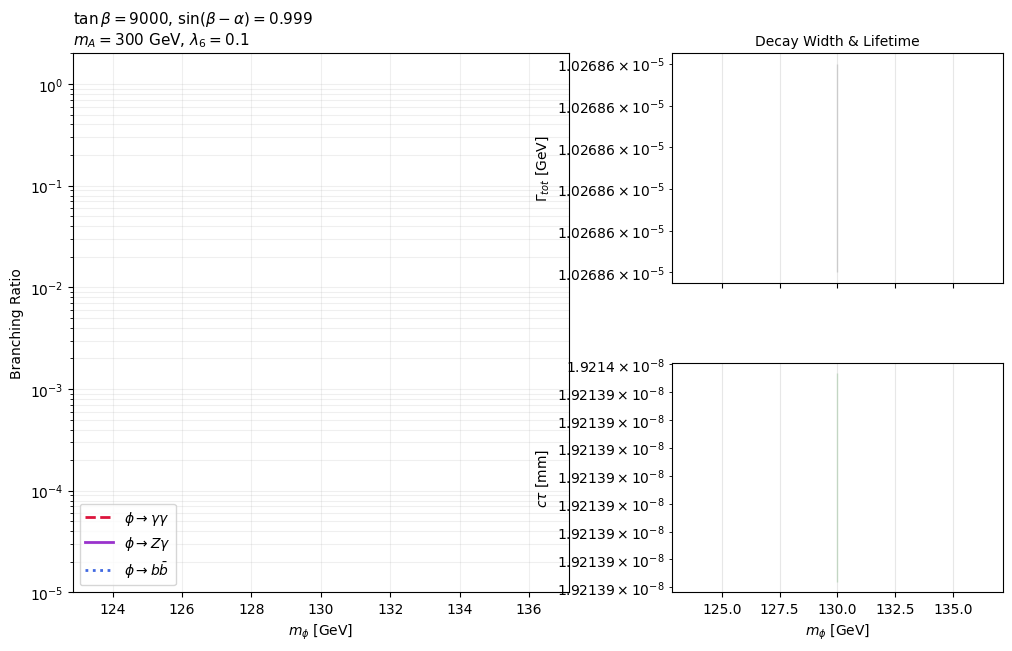

      📈 Ploteando tanβ=10000.0 (N=3808)


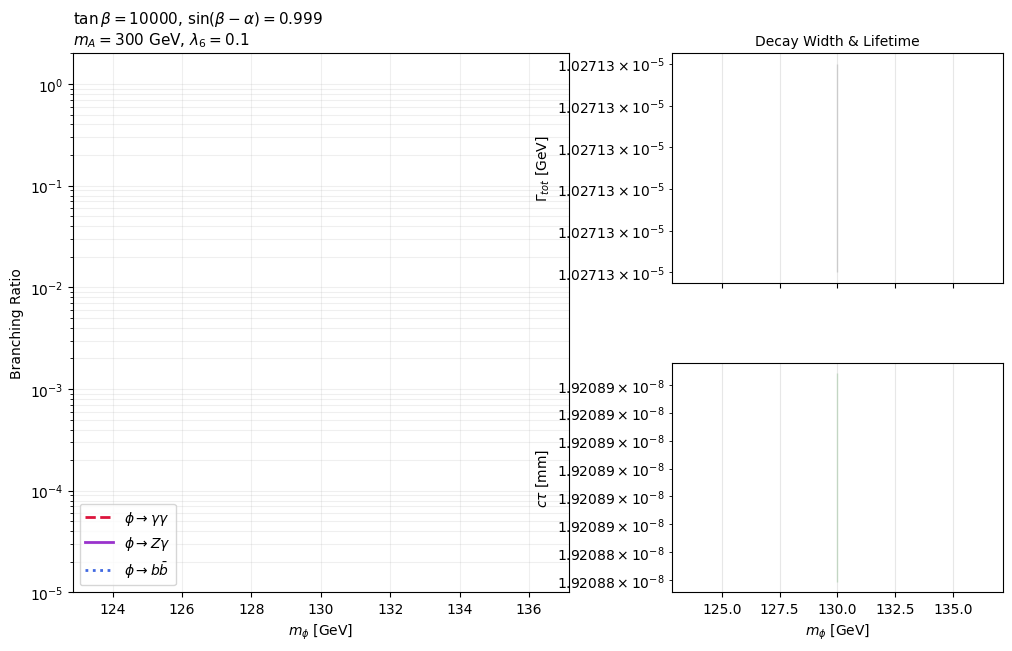

   👉 sin(b-a)=0.9995
      📈 Ploteando tanβ=10000.0 (N=1739)


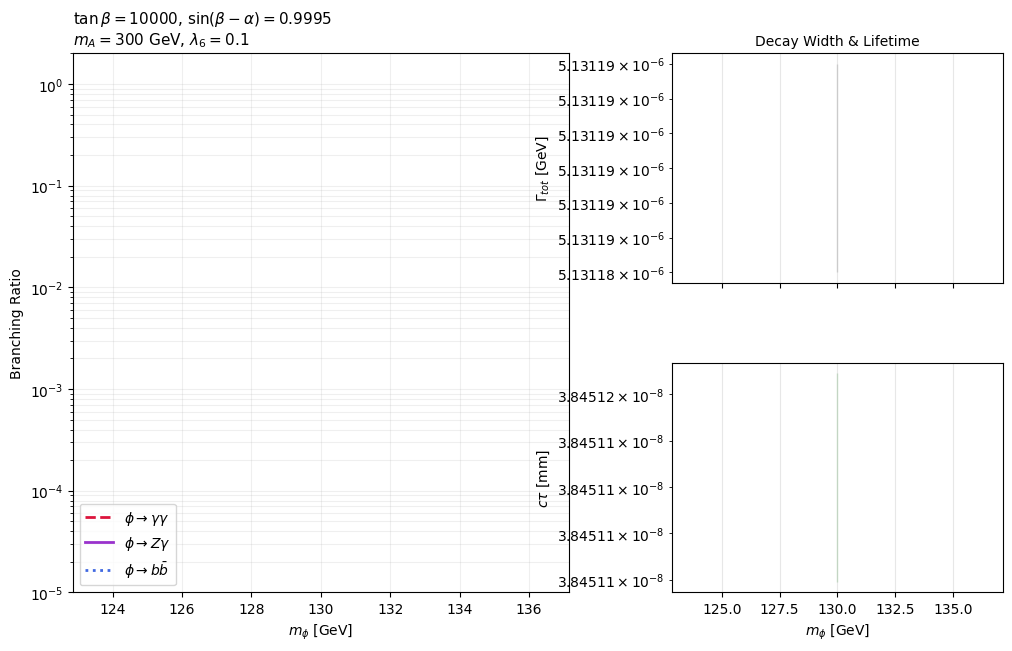

   👉 sin(b-a)=0.9999
      📈 Ploteando tanβ=100.0 (N=26035)


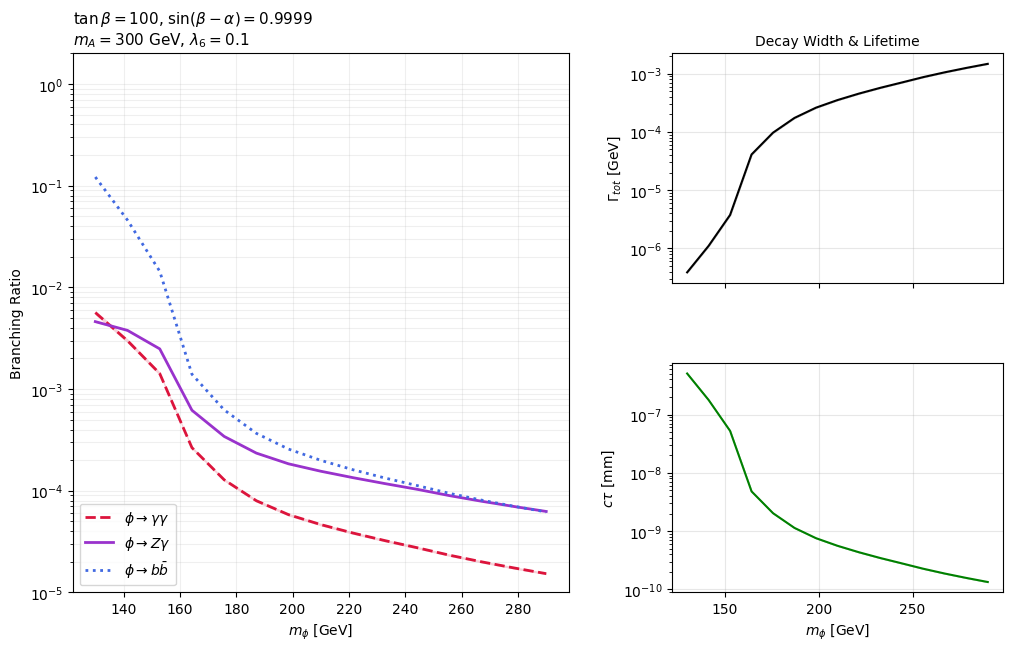

      📈 Ploteando tanβ=1000.0 (N=19166)


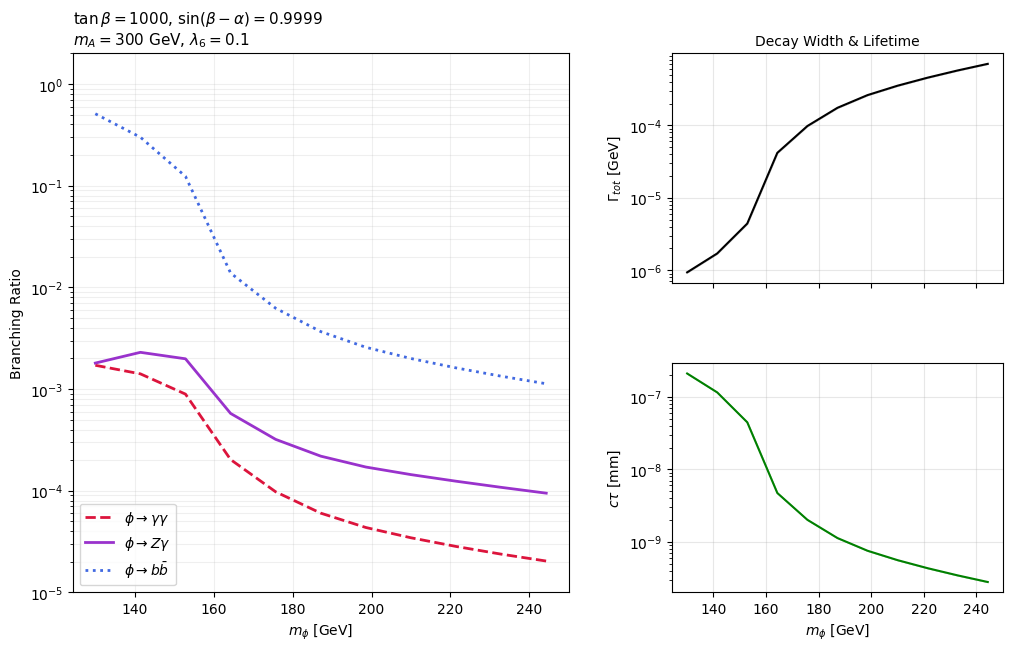

      📈 Ploteando tanβ=5000.0 (N=5229)


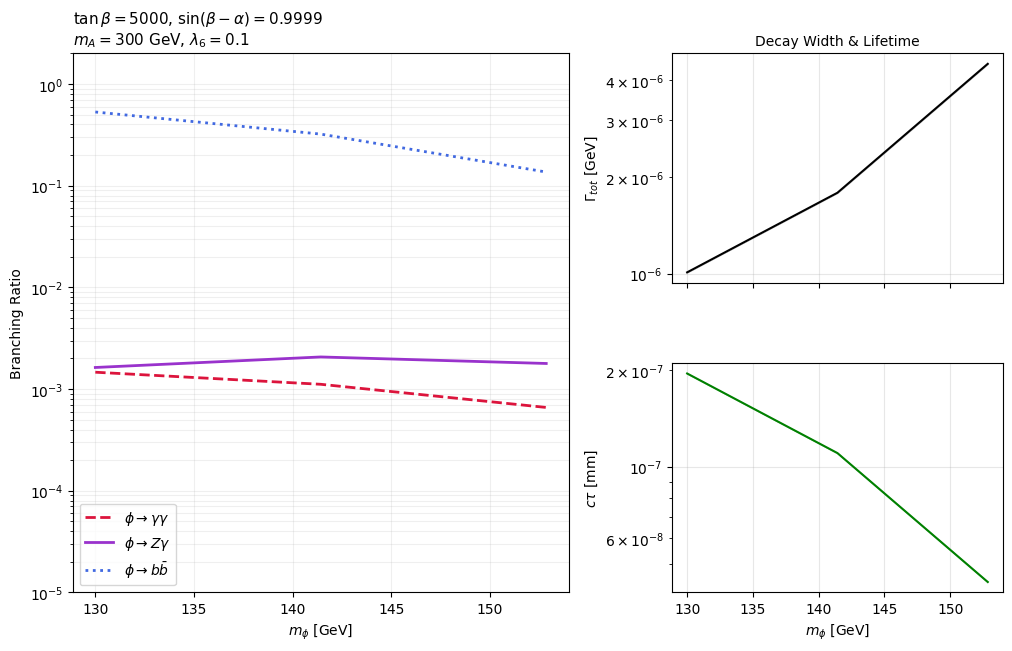

      📈 Ploteando tanβ=10000.0 (N=17436)


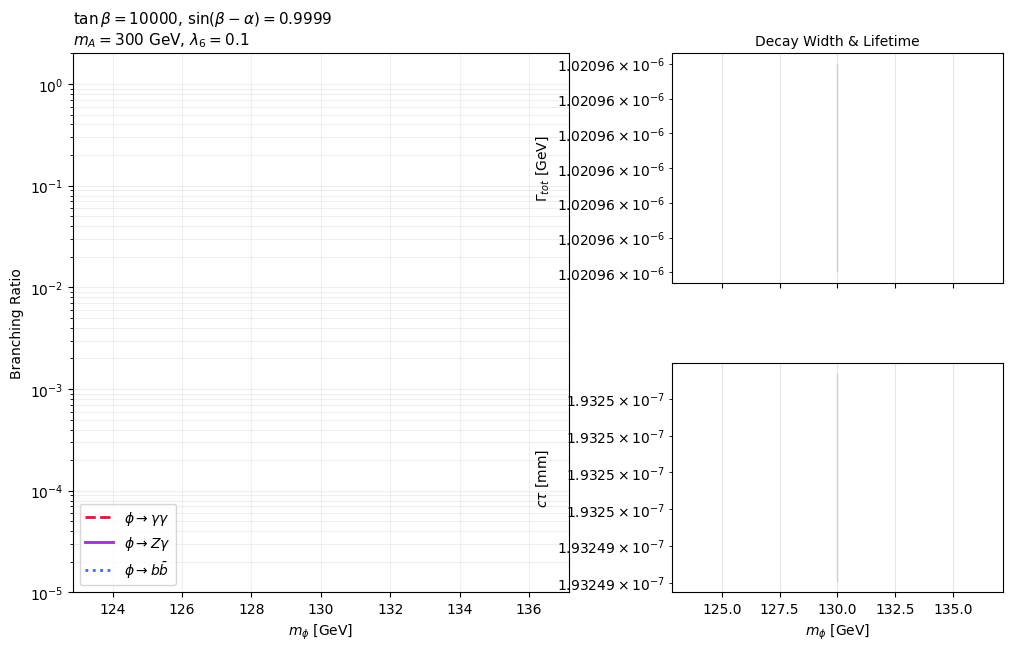

      📈 Ploteando tanβ=15000.0 (N=17442)


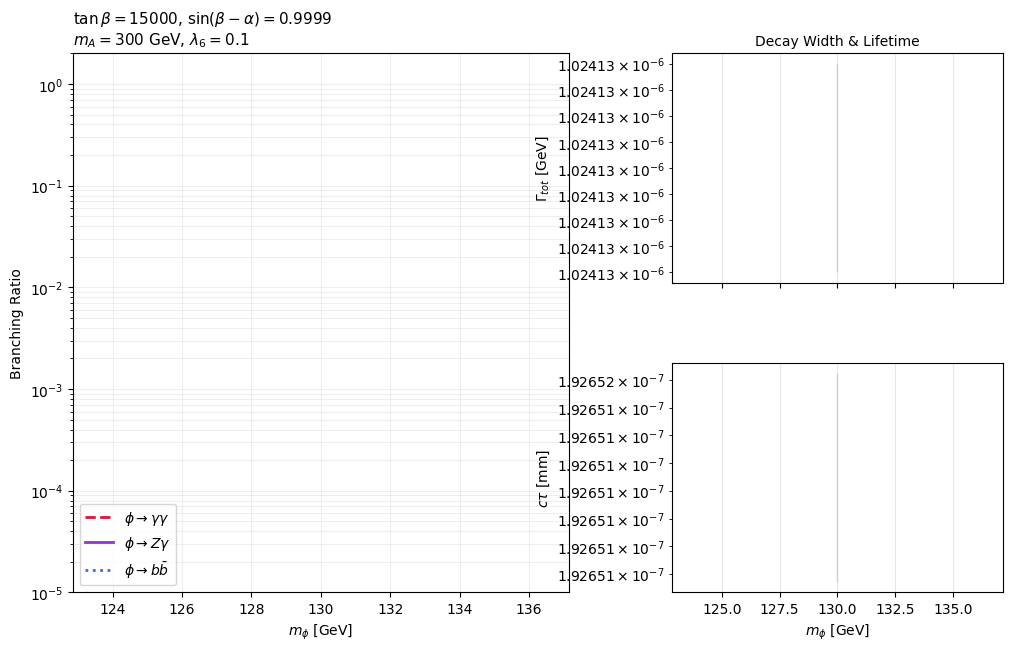

      📈 Ploteando tanβ=20000.0 (N=17444)


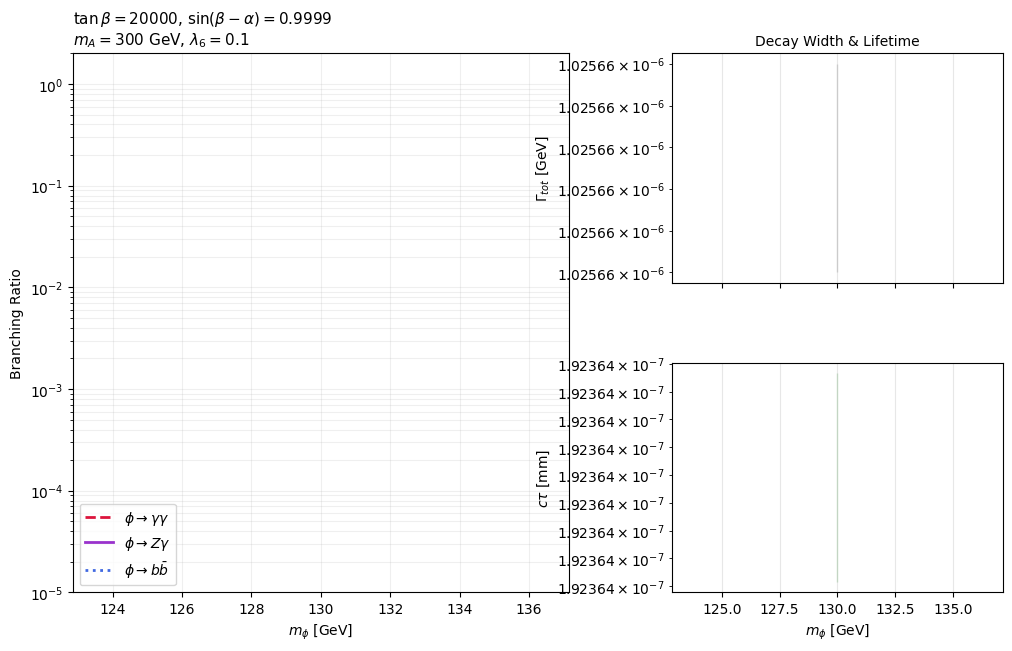

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import os

# ==============================================================================
# 1. FUNCIÓN DE VISUALIZACIÓN AVANZADA (Bandas de Confianza)
# ==============================================================================
def plot_branchings_with_bands(results: list, subplot_tag: str = "", lifetime_unit: str = "mm"):
    """
    Plotea Branching Ratios y Vida Media usando bandas de confianza (min-max) 
    para manejar la superposición de puntos físicos.
    """
    # --- Extracción de Datos ---
    channels = ['gaga', 'Zga', 'bb']
    # Convertimos a arrays numpy para vectorización
    mphi_raw = np.array([r['mphi'] for r in results])
    data = {ch: np.array([r['br'][ch] for r in results]) for ch in channels}
    width_raw = np.array([r['total_width'] for r in results])
    
    # Filtrar solo puntos físicos
    valid_mask = np.array([
        all(r['flags'][f] == 1 for f in ['positivity', 'unitarity', 'perturbativity'])
        for r in results
    ])
    
    if not np.any(valid_mask):
        print(f"   ⚠️ [Plotter] No hay puntos físicos válidos. Saltando plot.")
        return

    # Aplicar máscara
    mphi = mphi_raw[valid_mask]
    data_phys = {ch: vals[valid_mask] for ch, vals in data.items()}
    width_phys = width_raw[valid_mask]

    # --- Binning para Bandas (Agrupar por masa única) ---
    unique_masses = np.unique(mphi)
    stats = {ch: {'mean': [], 'min': [], 'max': []} for ch in channels}
    width_stats = {'mean': [], 'min': [], 'max': []}

    for m in unique_masses:
        mask_m = (mphi == m)
        # BRs
        for ch in channels:
            vals = data_phys[ch][mask_m]
            stats[ch]['mean'].append(np.mean(vals))
            stats[ch]['min'].append(np.min(vals))
            stats[ch]['max'].append(np.max(vals))
        # Width
        w_vals = width_phys[mask_m]
        width_stats['mean'].append(np.mean(w_vals))
        width_stats['min'].append(np.min(w_vals))
        width_stats['max'].append(np.max(w_vals))

    # Convertir a arrays
    for ch in channels: 
        for k in stats[ch]: stats[ch][k] = np.array(stats[ch][k])
    for k in width_stats: width_stats[k] = np.array(width_stats[k])

    # --- PLOTTING ---
    fig = plt.figure(figsize=(12, 7))
    gs = gridspec.GridSpec(2, 2, width_ratios=[1.2, 0.8], wspace=0.25, hspace=0.35)

    # Panel A: Branching Ratios
    ax_br = fig.add_subplot(gs[:, 0])
    colors = {'gaga': 'crimson', 'Zga': 'darkorchid', 'bb': 'royalblue'}
    styles = {'gaga': '--', 'Zga': '-', 'bb': ':'}
    labels = {'gaga': r'$\phi \to \gamma\gamma$', 'Zga': r'$\phi \to Z\gamma$', 'bb': r'$\phi \to b\bar{b}$'}

    for ch in channels:
        # Línea central
        ax_br.plot(unique_masses, stats[ch]['mean'], color=colors[ch], ls=styles[ch], lw=2, label=labels[ch])
        # Banda de confianza
        ax_br.fill_between(unique_masses, stats[ch]['min'], stats[ch]['max'], color=colors[ch], alpha=0.2, lw=0)

    ax_br.set_yscale('log')
    ax_br.set_ylim(1e-5, 2.0)
    ax_br.set_xlabel(r'$m_\phi$ [GeV]')
    ax_br.set_ylabel('Branching Ratio')
    ax_br.legend(loc='lower left', frameon=True)
    ax_br.set_title(subplot_tag, loc='left', fontsize=11)
    ax_br.grid(True, which="both", alpha=0.2)

    # Panel B: Decay Width
    ax_w = fig.add_subplot(gs[0, 1])
    ax_w.plot(unique_masses, width_stats['mean'], 'k-', lw=1.5)
    ax_w.fill_between(unique_masses, width_stats['min'], width_stats['max'], color='gray', alpha=0.3)
    ax_w.set_yscale('log')
    ax_w.set_ylabel(r'$\Gamma_{tot}$ [GeV]')
    ax_w.set_xticklabels([])
    ax_w.grid(True, alpha=0.3)
    ax_w.set_title("Decay Width & Lifetime", fontsize=10)

    # Panel C: Lifetime
    ax_tau = fig.add_subplot(gs[1, 1])
    hbar_c = 1.973e-13 # GeV mm
    scale = 1.0 if lifetime_unit == "mm" else 0.1
    
    ctau_mean = hbar_c / width_stats['mean']
    ctau_min  = hbar_c / width_stats['max'] # Inverso
    ctau_max  = hbar_c / width_stats['min']

    ax_tau.plot(unique_masses, ctau_mean * scale, 'g-', lw=1.5)
    ax_tau.fill_between(unique_masses, ctau_min * scale, ctau_max * scale, color='green', alpha=0.2)
    ax_tau.set_yscale('log')
    ax_tau.set_xlabel(r'$m_\phi$ [GeV]')
    ax_tau.set_ylabel(rf'$c\tau$ [{lifetime_unit}]')
    ax_tau.grid(True, alpha=0.3)

    plt.show()

# ==============================================================================
# 2. LÓGICA DE ITERACIÓN (Automática)
# ==============================================================================
# Asumimos que df_physical ya existe
unique_mAs      = sorted(df_physical['mA'].unique())
unique_l6s      = sorted(df_physical['lambda6'].unique())
unique_l7s      = sorted(df_physical['lambda7'].unique())
unique_sin_bas  = sorted(df_physical['sin_ba'].unique())

print(f"🔍 Espacio de parámetros detectado: {len(unique_mAs)} mA, {len(unique_sin_bas)} sin(b-a)")

def build_results_subset(subset, params_dict):
    """Convierte DF filtrado a lista de dicts para el plotter"""
    subset = subset.sort_values(by='m_phi')
    results = []
    for _, row in subset.iterrows():
        total_w = row['total_width']
        if pd.isna(total_w) or total_w <= 0:
            br_Zga, br_bb = 0.0, 0.0
        else:
            br_Zga = row['width_Zga'] / total_w
            br_bb  = row['width_bb']  / total_w

        entry = {
            'mphi': float(row['m_phi']),
            'br': {'gaga': float(row['br_gaga']), 'Zga': float(br_Zga), 'bb': float(br_bb)},
            'total_width': float(total_w) if total_w else 0.0,
            'flags': {'positivity': 1, 'unitarity': 1, 'perturbativity': 1},
            'params': params_dict
        }
        results.append(entry)
    return results

# Bucle Maestro
for ma in unique_mAs:
    for l6 in unique_l6s:
        for l7 in unique_l7s:
            # Filtro Escenario
            df_scen = df_physical[(df_physical.mA == ma) & (df_physical.lambda6 == l6)]
            if df_scen.empty: continue
            
            print(f"\n📍 Escenario: mA={ma}, l6={l6}")

            for sba in unique_sin_bas:
                df_sin = df_scen[df_scen.sin_ba == sba]
                if df_sin.empty: continue
                
                print(f"   👉 sin(b-a)={sba}")
                
                # Iterar TanBeta
                for tb in sorted(df_sin.tan_beta.unique()):
                    df_final = df_sin[df_sin.tan_beta == tb]
                    if len(df_final) < 5: continue 

                    print(f"      📈 Ploteando tanβ={tb} (N={len(df_final)})")
                    
                    params = {'mA': ma, 'lambda6': l6, 'lambda7': l7, 'sin_ba': sba, 'tan_beta': tb}
                    res = build_results_subset(df_final, params)
                    
                    title = (fr"$\tan\beta={tb:.0f}$, $\sin(\beta-\alpha)={sba}$"
                             f"\n$m_A={ma:.0f}$ GeV, $\lambda_6={l6}$")
                    
                    try:
                        plot_branchings_with_bands(res, subplot_tag=title)
                    except Exception as e:
                        print(f"      ❌ Error: {e}")

In [26]:
# === CELDA A: Enriquecimiento del DataFrame ===
import numpy as np
import pandas as pd

# Constante hbar*c en GeV*mm
HBAR_C_MM = 1.973269804e-13 

print("⚙️ Calculando variables derivadas para análisis...")

# Trabajamos sobre una copia para no alterar el original inadvertidamente
df_analysis = df_physical.copy()

# 1. Cálculo de ctau [mm] (Vida Media)
# ctau = (hbar * c) / Gamma_tot
# Usamos un epsilon para evitar divisiones por cero
epsilon = 1e-99
if "total_width" in df_analysis.columns:
    df_analysis["ctau_mm"] = HBAR_C_MM / df_analysis["total_width"].replace(0, epsilon)
else:
    print("⚠️ 'total_width' no encontrado. No se puede calcular ctau.")

# 2. Cálculo de BR(bb) si no existe explícitamente pero tenemos anchos parciales
if "br_bb" not in df_analysis.columns and "width_bb" in df_analysis.columns:
    df_analysis["br_bb"] = df_analysis["width_bb"] / df_analysis["total_width"].replace(0, epsilon)

# 3. Verificación rápida
print(f"📊 DataFrame listo para análisis: {len(df_analysis)} puntos.")
print(f"   Rango ctau: [{df_analysis['ctau_mm'].min():.2e}, {df_analysis['ctau_mm'].max():.2e}] mm")

⚙️ Calculando variables derivadas para análisis...
📊 DataFrame listo para análisis: 259918 puntos.
   Rango ctau: [5.04e-14, 5.07e-07] mm


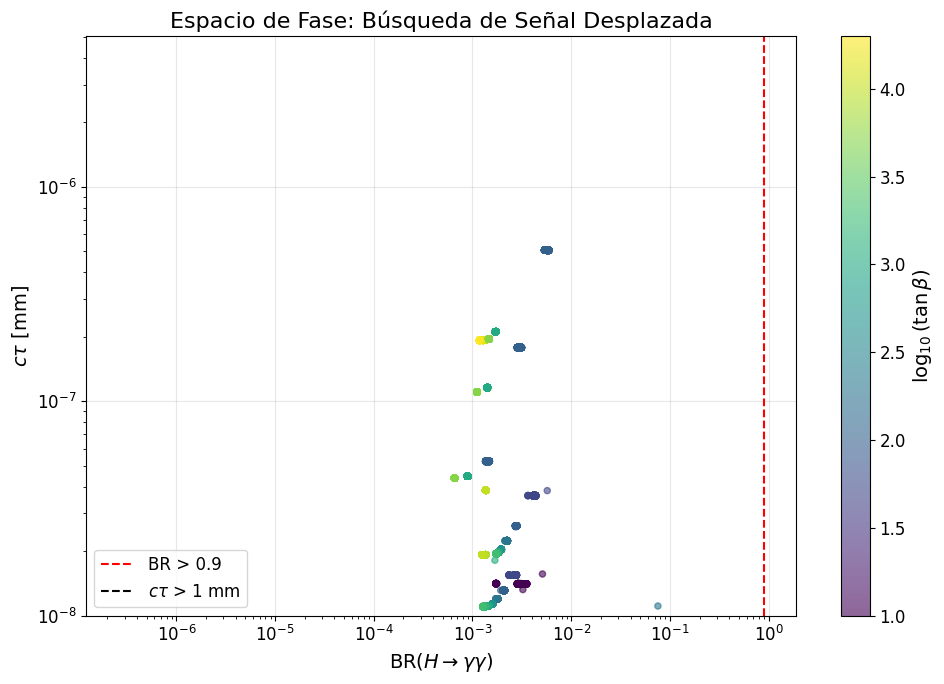

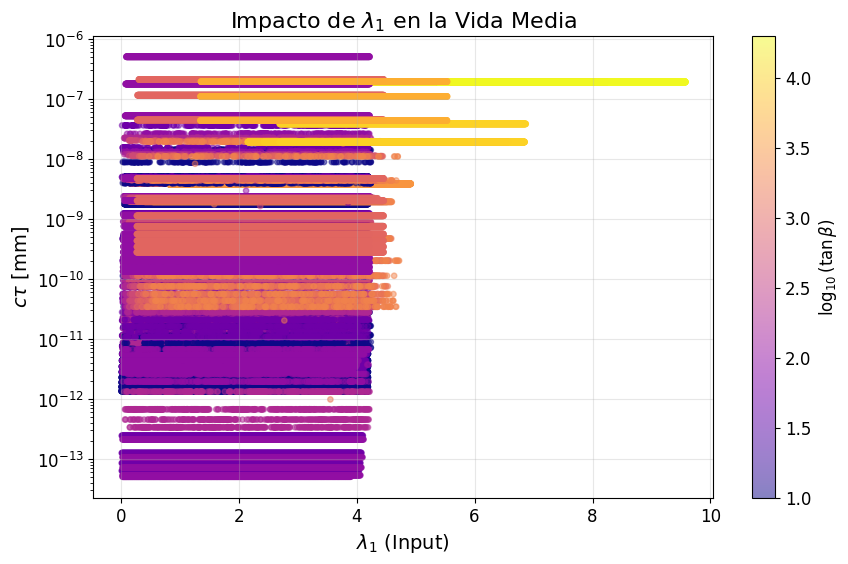

In [31]:
# === CELDA B: Visualización del Espacio de Fase ===
import matplotlib.pyplot as plt
import numpy as np

# Configuración de estilo
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# --- 1. Espacio de Fase: BR vs Vida Media ---
fig, ax = plt.subplots(figsize=(10, 7))

# Coloreamos por tan_beta para ver la dependencia
sc = ax.scatter(
    df_analysis["br_gaga"], 
    df_analysis["ctau_mm"], 
    c=np.log10(df_analysis["tan_beta"]), 
    cmap='viridis', 
    alpha=0.6,
    s=20
)

cbar = plt.colorbar(sc)
cbar.set_label(r'$\log_{10}(\tan\beta)$', fontsize=14)

# Líneas de referencia para la región de interés
ax.axvline(0.9, color='r', linestyle='--', label='BR > 0.5')
ax.axhline(1.0, color='k', linestyle='--', label=r'$c\tau$ > 1 mm')

ax.set_xlabel(r'BR($H \to \gamma\gamma$)', fontsize=14)
ax.set_ylabel(r'$c\tau$ [mm]', fontsize=14)
ax.set_yscale('log')
ax.set_xscale('log')
# ax.set_xlim(0.0, 1.05) 
ax.set_ylim(bottom=1e-8, top=df_analysis["ctau_mm"].max()*10) # Ajuste dinámico

ax.set_title("Espacio de Fase: Búsqueda de Señal Desplazada", fontsize=16)
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 2. Sensibilidad a Lambda 1 ---
# Importante para ver qué parámetro del potencial controla esto
if "lam1" in df_analysis.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    sc = ax.scatter(
        df_analysis["lam1"], 
        df_analysis["ctau_mm"], 
        c=np.log10(df_analysis["tan_beta"]), 
        cmap='plasma', 
        alpha=0.5, 
        s=15
    )
    cbar = plt.colorbar(sc)
    cbar.set_label(r'$\log_{10}(\tan\beta)$', fontsize=12)
    
    ax.set_xlabel(r'$\lambda_1$ (Input)', fontsize=14)
    ax.set_ylabel(r'$c\tau$ [mm]', fontsize=14)
    ax.set_yscale('log')

    ax.set_title(r"Impacto de $\lambda_1$ en la Vida Media", fontsize=16)
    ax.grid(True, alpha=0.3)
    plt.show()

🏆 Iniciando Análisis de Pareto (Búsqueda de la Frontera Eficiente)...
       REPORTE DE ÉLITE (TOP 3 PUNTOS)

1. Configuración Óptima Sugerida (Basada en la media):
   -> Masa H:    213.8 ± 46.2 GeV
   -> TanBeta:   250.0 (Rango: 50.0 - 500.0)

2. Rendimiento Esperado:
   -> Vida Media: 0.00 mm  <--> 0.0 mm
   -> BR(gaga):   0.0486 <--> 0.0756

3. Parámetro Crítico Lambda_1:
   -> Rango: [0.5285, 0.9489]
   -> Media: 0.7207


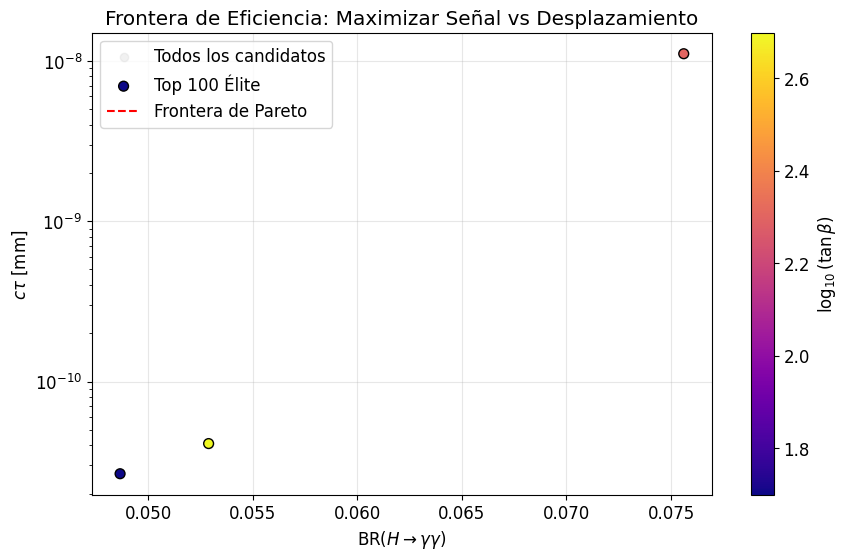


[EXPORT] Reporte detallado guardado en 'elite_candidates_report.csv'


In [33]:
# === CELDA C: Reporte de Élite (Análisis de Pareto) ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuración de Límites Físicos del Detector
CTAU_MAX_MM = 7000.0  # Límite del detector (7 metros)
BR_MIN_THRESHOLD = 0.01 # Mínimo interés físico

print("🏆 Iniciando Análisis de Pareto (Búsqueda de la Frontera Eficiente)...")

# 1. Pre-filtrado (Solo puntos físicamente útiles)
candidates = df_analysis[
    (df_analysis["ctau_mm"] < CTAU_MAX_MM) & 
    (df_analysis["br_gaga"] > BR_MIN_THRESHOLD)
].copy()

if candidates.empty:
    print("❌ No hay candidatos viables dentro del detector.")
else:
    # 2. Cálculo de Dominancia (Pareto)
    # Queremos MAXIMIZAR BR y MAXIMIZAR ctau (hasta el límite del detector)
    # Un punto A domina a B si: BR_A >= BR_B y ctau_A >= ctau_B (y al menos uno es estricto)
    
    # Ordenamos por BR descendente para optimizar la búsqueda
    candidates = candidates.sort_values(by="br_gaga", ascending=False)
    
    pareto_front = []
    current_max_ctau = -1.0
    
    # Algoritmo de barrido simple para 2D (O(N log N))
    for idx, row in candidates.iterrows():
        if row["ctau_mm"] > current_max_ctau:
            pareto_front.append(row)
            current_max_ctau = row["ctau_mm"]
            
    df_pareto = pd.DataFrame(pareto_front)
    
    # 3. Selección de los "Top 100" (La Élite)
    # Si la frontera tiene < 100 puntos, rellenamos con los siguientes mejores (sub-frontera)
    # Para simplificar, tomamos el Top 100 por una métrica combinada de "Señales Desplazadas"
    # Score ~ BR * log10(ctau)  (Dando peso al desplazamiento)
    candidates["score"] = candidates["br_gaga"] * np.log10(candidates["ctau_mm"] + 1e-9)
    df_elite = candidates.sort_values(by="score", ascending=False).head(100)
    
    # ==========================================
    # REPORTE ESTADÍSTICO
    # ==========================================
    print("="*60)
    print(f"       REPORTE DE ÉLITE (TOP {len(df_elite)} PUNTOS)")
    print("="*60)
    
    stats = df_elite[["m_phi", "tan_beta", "ctau_mm", "br_gaga"]].describe()
    
    print(f"\n1. Configuración Óptima Sugerida (Basada en la media):")
    print(f"   -> Masa H:    {stats.loc['mean', 'm_phi']:.1f} ± {stats.loc['std', 'm_phi']:.1f} GeV")
    print(f"   -> TanBeta:   {stats.loc['mean', 'tan_beta']:.1f} (Rango: {stats.loc['min', 'tan_beta']:.1f} - {stats.loc['max', 'tan_beta']:.1f})")
    
    print(f"\n2. Rendimiento Esperado:")
    print(f"   -> Vida Media: {stats.loc['min', 'ctau_mm']:.2f} mm  <--> {stats.loc['max', 'ctau_mm']:.1f} mm")
    print(f"   -> BR(gaga):   {stats.loc['min', 'br_gaga']:.4f} <--> {stats.loc['max', 'br_gaga']:.4f}")

    if "lam1" in df_elite.columns:
         print(f"\n3. Parámetro Crítico Lambda_1:")
         l1_stats = df_elite["lam1"].describe()
         print(f"   -> Rango: [{l1_stats['min']:.4f}, {l1_stats['max']:.4f}]")
         print(f"   -> Media: {l1_stats['mean']:.4f}")

    # ==========================================
    # VISUALIZACIÓN DE LA FRONTERA
    # ==========================================
    plt.figure(figsize=(10, 6))
    
    # Puntos de fondo (gris)
    plt.scatter(candidates["br_gaga"], candidates["ctau_mm"], color='lightgray', alpha=0.3, label='Todos los candidatos')
    
    # Puntos de Élite (coloreados por TanBeta)
    sc = plt.scatter(df_elite["br_gaga"], df_elite["ctau_mm"], 
                     c=np.log10(df_elite["tan_beta"]), cmap='plasma', 
                     edgecolors='k', s=50, label='Top 100 Élite')
    
    # Frontera de Pareto (Línea)
    if not df_pareto.empty:
        plt.plot(df_pareto["br_gaga"], df_pareto["ctau_mm"], 'r--', lw=1.5, label='Frontera de Pareto')

    plt.colorbar(sc, label=r'$\log_{10}(\tan\beta)$')
    plt.yscale('log')
    plt.xlabel(r'BR($H \to \gamma\gamma$)')
    plt.ylabel(r'$c\tau$ [mm]')
    plt.title("Frontera de Eficiencia: Maximizar Señal vs Desplazamiento")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Guardar reporte
    df_elite.to_csv("elite_candidates_report.csv", index=False)
    print(f"\n[EXPORT] Reporte detallado guardado en 'elite_candidates_report.csv'")

## LifeTime

[WARNING] No hay datos para tanβ=3000.0
[WARNING] No hay datos para tanβ=5000.0
[WARNING] No hay datos para tanβ=15000.0
[WARNING] No hay datos para tanβ=20000.0


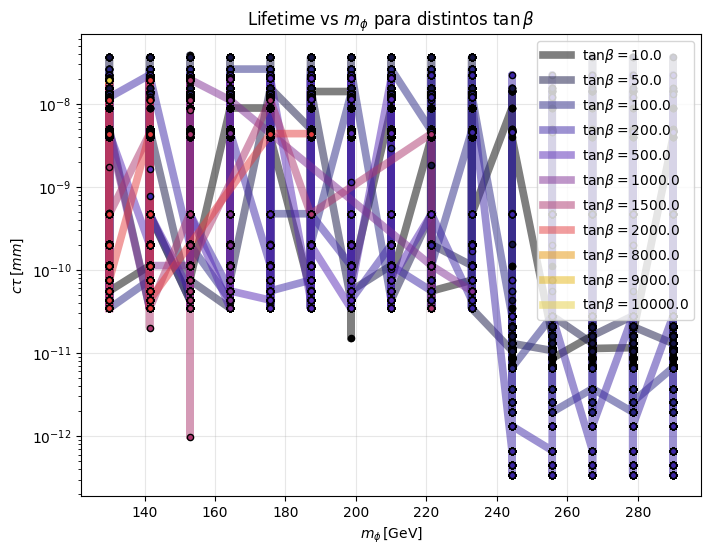

In [22]:
import matplotlib.pyplot as plt
import numpy as np

def plot_lifetime_vs_mphi(
    df_curve,
    tan_betas,
    lifetime_unit: str = "mm",
    lifetime_log: bool = True
):
    """
    Plotea la vida media cτ(m_phi) para distintos slices de tan_beta.

    df_curve: DataFrame filtrado (ya con parámetros fijos excepto tan_beta).
    tan_betas: lista de valores de tan_beta a recorrer.
    lifetime_unit: "mm", "cm" o "m".
    lifetime_log: True → eje y en escala log.
    """
    # Constantes
    hbar = 6.582119569e-25    # GeV·s
    c    = 2.99792458e11      # mm/s
    unit_factors = {"mm": 1.0, "cm": 0.1, "m": 1e-3}
    if lifetime_unit not in unit_factors:
        raise ValueError(f"Unknown lifetime_unit '{lifetime_unit}'")

    plt.figure(figsize=(8,6))
    cmap = plt.cm.CMRmap#plt.cm.viridis
    colors = [cmap(i/len(tan_betas)) for i in range(len(tan_betas))]

    for i, tb in enumerate(tan_betas):
        subset = df_curve[np.isclose(df_curve["tan_beta"], tb, rtol=1e-5)]
        if subset.empty:
            print(f"[WARNING] No hay datos para tanβ={tb}")
            continue

        mphi = subset["m_phi"].values
        total_w = subset["total_width"].values
        c_tau_mm = hbar * c / total_w
        c_tau = c_tau_mm * unit_factors[lifetime_unit]

        # Ordenar por mphi para líneas limpias
        order = np.argsort(mphi)
        mphi, c_tau = mphi[order], c_tau[order]

        plt.plot(mphi, c_tau, label=fr"tan$\beta={tb}$", color=colors[i], lw=5.5, alpha=0.5)
        plt.scatter(mphi, c_tau, color=colors[i], edgecolors="k", s=20, zorder=5)

    plt.xlabel(r"$m_\phi\,[\mathrm{GeV}]$")
    plt.ylabel(rf"$c\tau\,[{lifetime_unit}]$")
    if lifetime_log:
        plt.yscale("log")
    plt.title(r"Lifetime vs $m_\phi$ para distintos $\tan \beta$")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

tan_betas = sorted(set(df_physical.tan_beta))
plot_lifetime_vs_mphi(df_curve, tan_betas, lifetime_unit="mm", lifetime_log=True)
